## Imports

In [1]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio import features
import numpy as np
import matplotlib.pyplot as plt
from pystac_client import Client
from odc.stac import load
import os
from shapely import geometry
from shapely.geometry import box
from sklearn.model_selection import train_test_split

In [3]:
import ee
import geemap

ee.Authenticate(force=True)
ee.Initialize()

EEException: Cannot authenticate: Invalid request.

## Dataset Exploration

In [3]:
# Define the path to your GeoPackage (update this to match your actual file name)
gpkg_path = "global_pv_facility_inventory.gpkg" 

# Note: GeoPackages can technically hold multiple "layers" (like sheets in Excel). 
# gpd.read_file() defaults to reading the first one, which is usually what you want.
gdf = gpd.read_file(gpkg_path)

# 1. Print the columns
print("--- Column Names ---")
print(gdf.columns.tolist())
print("\n")

# 2. Get a high-level summary (counts, null values, data types)
print("--- Dataset Info ---")
gdf.info()
print("\n")

# 3. Display the first 5 rows (Jupyter will format this nicely as an HTML table)
display(gdf.head())

--- Column Names ---
['PV_ID', 'latitude', 'longitude', 'country', 'year', 'area_m2', 'geometry']


--- Dataset Info ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 140945 entries, 0 to 140944
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   PV_ID      140945 non-null  int64   
 1   latitude   140945 non-null  float64 
 2   longitude  140945 non-null  float64 
 3   country    140945 non-null  str     
 4   year       140945 non-null  int64   
 5   area_m2    140945 non-null  float64 
 6   geometry   140945 non-null  geometry
dtypes: float64(3), geometry(1), int64(2), str(1)
memory usage: 7.5 MB




,PV_ID,latitude,longitude,country,year,area_m2,geometry
0,1,-41.608870,173.430371,New Zealand,2020,11306.795652,"MULTIPOLYGON (((173.42951 -41.60889, 173.42951..."
1,2,-41.607845,173.430263,New Zealand,2020,62.267310,"MULTIPOLYGON (((173.43025 -41.60789, 173.43025..."
2,3,-39.482263,174.171666,New Zealand,2021,22318.891560,"MULTIPOLYGON (((174.17238 -39.48182, 174.17235..."
3,4,-38.657410,177.981679,New Zealand,2023,37923.521044,"MULTIPOLYGON (((177.98231 -38.65698, 177.98242..."
4,5,-37.996383,176.808509,New Zealand,2024,367791.614147,"MULTIPOLYGON (((176.81401 -37.99611, 176.81401..."


In [4]:
# Check the Coordinate Reference System
print(f"Current CRS: {gdf.crs}")

# Calculate some basic spatial statistics
print(f"\nTotal number of solar sites: {len(gdf)}")

# Let's see the bounding box of the entire dataset (min/max X and Y coordinates)
print(f"Global Bounding Box: {gdf.total_bounds}")

Current CRS: EPSG:4326

Total number of solar sites: 140945
Global Bounding Box: [-171.99312244  -41.60993902  177.98359942   68.37908123]


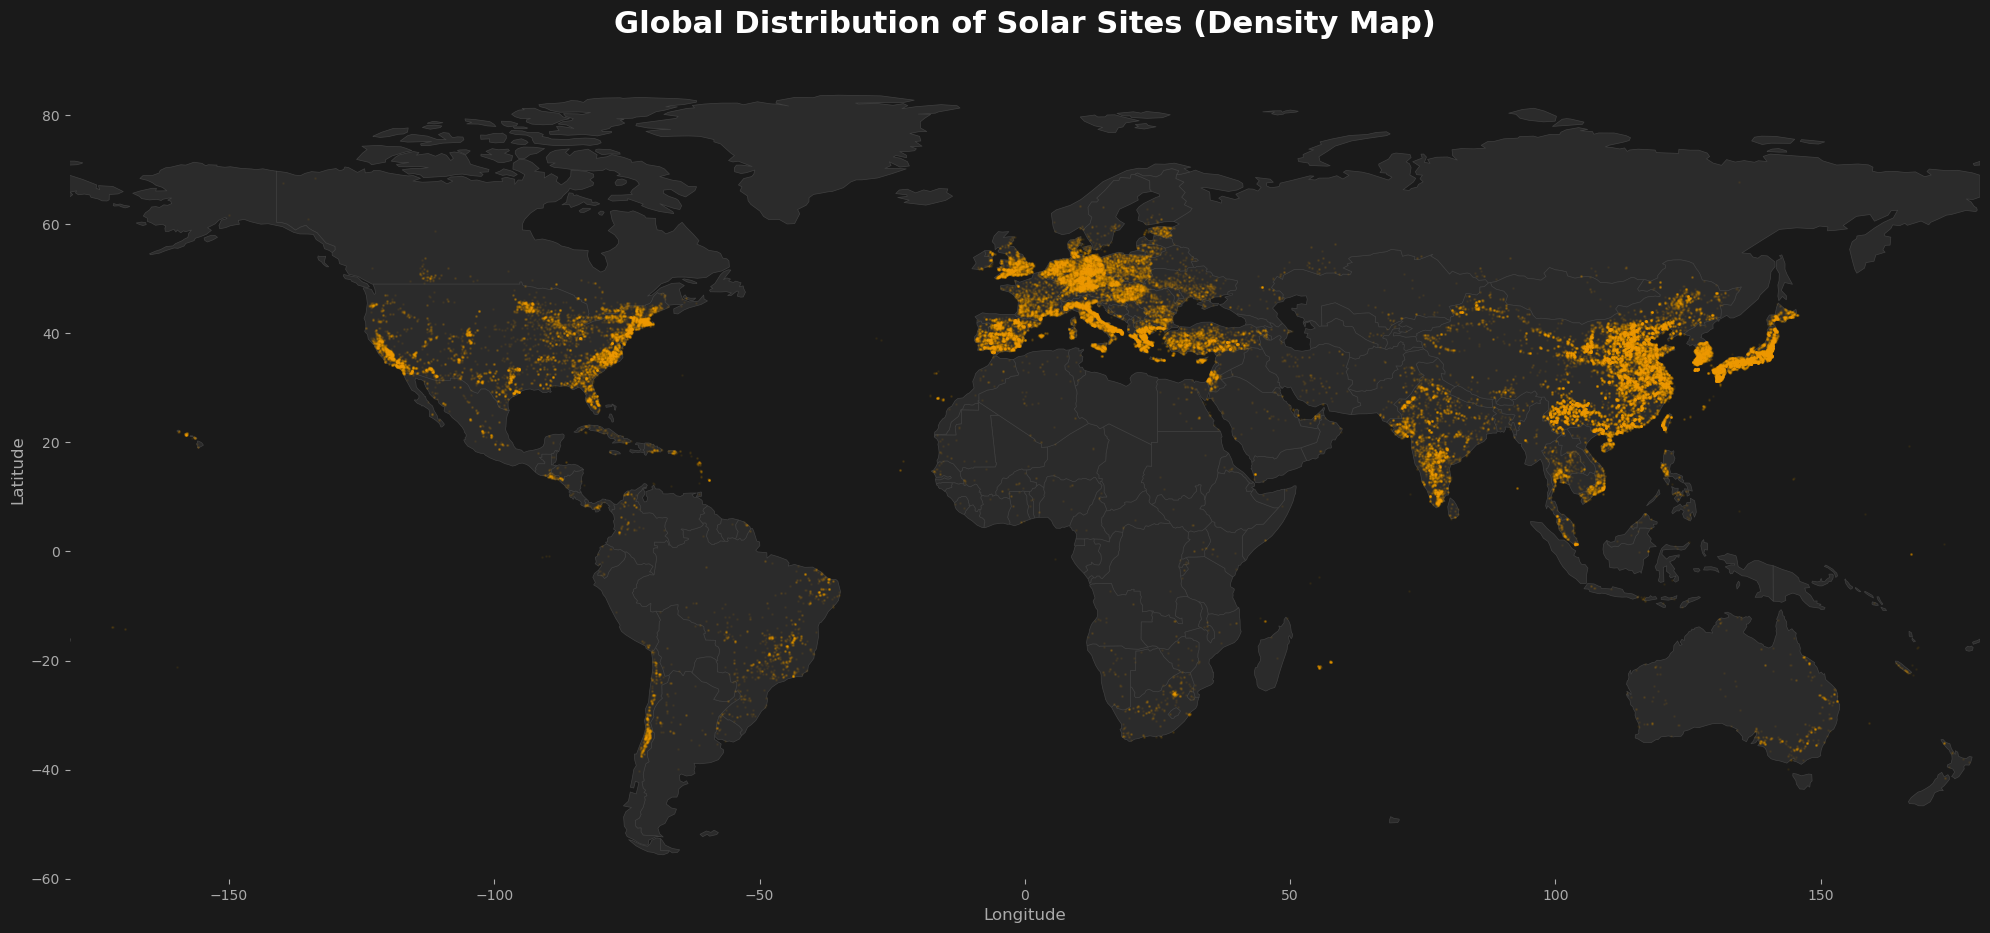

In [51]:

import warnings

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
# Make sure to replace 'gdf' with your actual global dataset variable name
global_points = gdf.copy()

print("Downloading global background map...")
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Convert polygons to centroids for fast plotting
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    global_points['geometry'] = global_points.geometry.centroid

# ==============================================================================
# 2. PLOT THE MAP (Dark Theme for Hotspot Effect)
# ==============================================================================
# Create a large, wide figure to accommodate the whole globe
fig, ax = plt.subplots(figsize=(20, 10))

# Set the background to dark charcoal
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

# Plot 1: The World Map (Dark grey land, slightly lighter borders)
world.plot(ax=ax, color='#2b2b2b', edgecolor='#404040', linewidth=0.5)

# Plot 2: The Solar Hotspots 
# markersize=1 makes them tiny, alpha=0.05 makes them transparent
# Color '#ffaa00' is a bright amber/orange that glows nicely on dark backgrounds
global_points.plot(ax=ax, color='#ffaa00', markersize=1, alpha=0.05)

# ==============================================================================
# 3. FORMATTING
# ==============================================================================
ax.set_title("Global Distribution of Solar Sites (Density Map)", 
             fontsize=22, fontweight='bold', color='white', pad=20)

# Clean up the axes colors for dark mode
ax.set_xlabel("Longitude", fontsize=12, color='#aaaaaa')
ax.set_ylabel("Latitude", fontsize=12, color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')

# Restrict the view to cut out Antarctica (which has no solar farms) and keep the map focused
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 90)

# Remove the outer spine borders for a cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

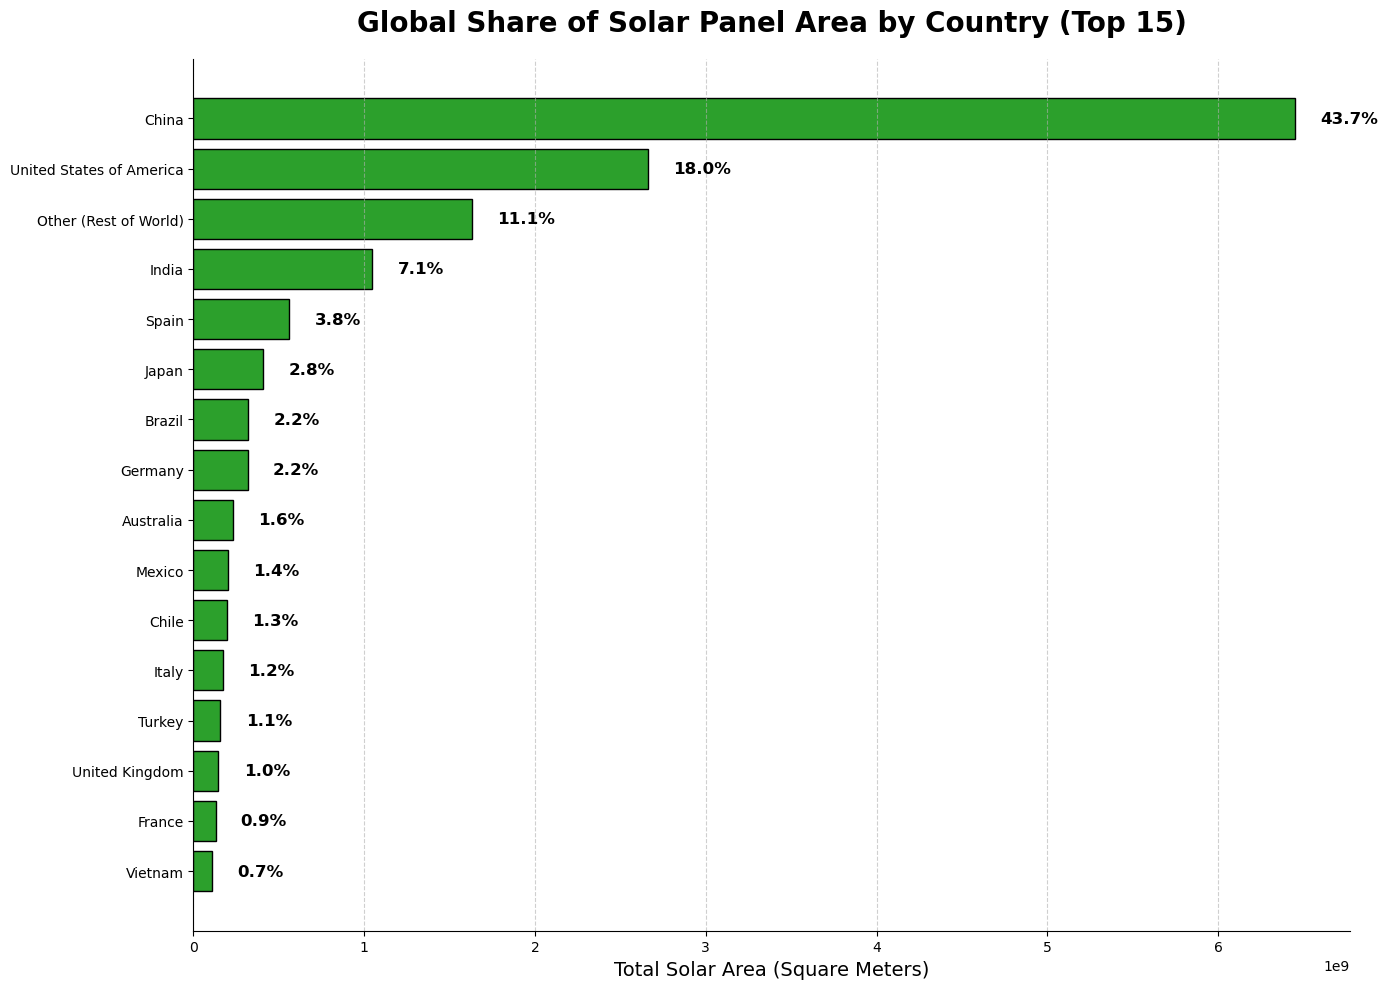

In [55]:
import matplotlib.pyplot as plt

# ==============================================================================
# 1. AGGREGATE THE DATA
# ==============================================================================
# If your global dataset already has a 'country' column, we group by that.
if 'country' in gdf.columns:
    area_by_country = gdf.groupby('country')['area_m2'].sum()
else:
    print("No 'country' column found. Performing spatial join to determine countries...")
    # Use the global_points and world map from the previous cell
    gdf_with_country = gpd.sjoin(global_points, world[['geometry', 'ADMIN']], how='left', predicate='intersects')
    area_by_country = gdf_with_country.groupby('ADMIN')['area_m2'].sum()

# Sort the countries from largest solar area to smallest
area_by_country = area_by_country.sort_values(ascending=False)

# ==============================================================================
# 2. CLEAN UP FOR VISUALIZATION (Top 10 + Other)
# ==============================================================================
# Keep the top 10 countries as individual slices
top_10 = area_by_country.head(15)

# Sum all the remaining countries into a single "Other" category
other_area = area_by_country.iloc[15:].sum()
other_series = pd.Series([other_area], index=['Other (Rest of World)'])

# Combine them for the final plot
plot_data = pd.concat([top_10, other_series])

fig, ax = plt.subplots(figsize=(14, 10))

# Sort the data ascending so the biggest bar ends up at the very top of the chart
plot_data_sorted = plot_data.sort_values(ascending=True)

# Generate horizontal bars
bars = ax.barh(plot_data_sorted.index, plot_data_sorted.values, color='#2ca02c', edgecolor='black')

ax.set_title("Global Share of Solar Panel Area by Country (Top 15)", fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel("Total Solar Area (Square Meters)", fontsize=14)

# Calculate the total area so we can append the percentages to the end of the bars
total_area = plot_data.sum()

# Loop through each bar and attach the percentage text just to the right of it
for bar in bars:
    width = bar.get_width()
    percentage = (width / total_area) * 100
    
    # Place text at the end of the bar (width), vertically centered
    ax.text(width + (total_area * 0.01), # Add a tiny bit of padding so it doesn't touch the bar
            bar.get_y() + bar.get_height()/2, 
            f'{percentage:.1f}%', 
            va='center', ha='left', fontsize=12, fontweight='bold')

# Add a background grid to make estimating values easier
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Remove the top and right borders for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

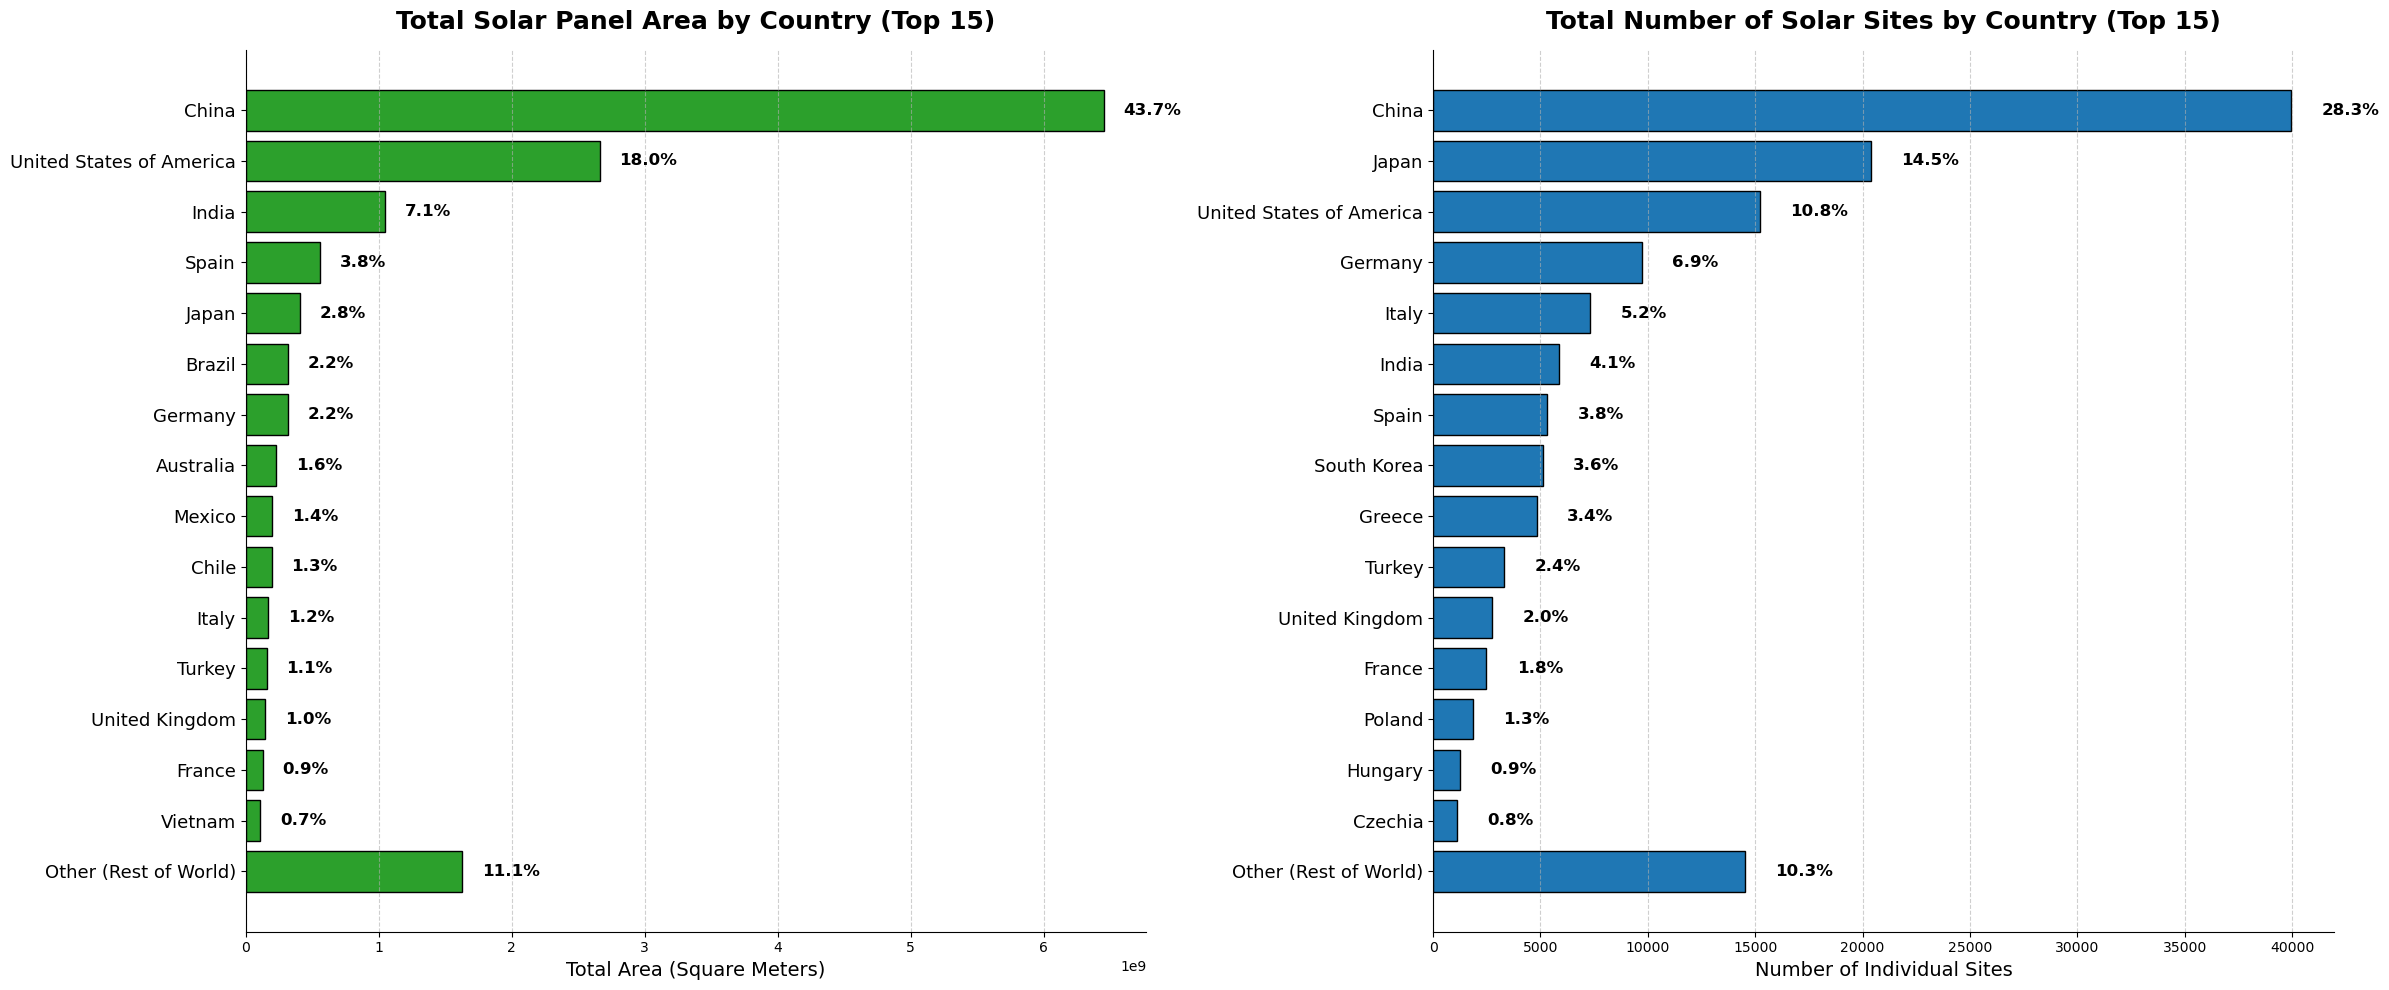

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

# ==============================================================================
# 1. AGGREGATE THE DATA (AREA AND COUNT)
# ==============================================================================
if 'country' in gdf.columns:
    area_by_country = gdf.groupby('country')['area_m2'].sum()
    count_by_country = gdf.groupby('country').size()
else:
    print("No 'country' column found. Performing spatial join...")
    gdf_with_country = gpd.sjoin(global_points, world[['geometry', 'ADMIN']], how='left', predicate='intersects')
    area_by_country = gdf_with_country.groupby('ADMIN')['area_m2'].sum()
    count_by_country = gdf_with_country.groupby('ADMIN').size()

# Sort descending to easily grab the Top 15
area_by_country = area_by_country.sort_values(ascending=False)
count_by_country = count_by_country.sort_values(ascending=False)

# ==============================================================================
# 2. FORMAT DATA & FORCE "OTHER" TO THE BOTTOM
# ==============================================================================
# ---- Area Data ----
top_15_area = area_by_country.head(15)
other_area = pd.Series([area_by_country.iloc[15:].sum()], index=['Other (Rest of World)'])
# By placing 'other_area' first, and sorting the rest ascending, "Other" locks to the bottom!
plot_data_area = pd.concat([other_area, top_15_area.sort_values(ascending=True)])

# ---- Count Data ----
top_15_count = count_by_country.head(15)
other_count = pd.Series([count_by_country.iloc[15:].sum()], index=['Other (Rest of World)'])
plot_data_count = pd.concat([other_count, top_15_count.sort_values(ascending=True)])

# ==============================================================================
# 3. PLOT THE SIDE-BY-SIDE DASHBOARD
# ==============================================================================
fig, axs = plt.subplots(1, 2, figsize=(24, 10))

# --- PLOT 1: Total Area ---
bars_area = axs[0].barh(plot_data_area.index, plot_data_area.values, color='#2ca02c', edgecolor='black')
axs[0].set_title("Total Solar Panel Area by Country (Top 15)", fontsize=18, fontweight='bold', pad=15)
axs[0].set_xlabel("Total Area (Square Meters)", fontsize=14)

total_area = plot_data_area.sum()
for bar in bars_area:
    width = bar.get_width()
    percentage = (width / total_area) * 100
    axs[0].text(width + (total_area * 0.01), bar.get_y() + bar.get_height()/2, 
                f'{percentage:.1f}%', va='center', ha='left', fontsize=12, fontweight='bold')

# --- PLOT 2: Number of Sites ---
bars_count = axs[1].barh(plot_data_count.index, plot_data_count.values, color='#1f77b4', edgecolor='black')
axs[1].set_title("Total Number of Solar Sites by Country (Top 15)", fontsize=18, fontweight='bold', pad=15)
axs[1].set_xlabel("Number of Individual Sites", fontsize=14)

total_count = plot_data_count.sum()
for bar in bars_count:
    width = bar.get_width()
    percentage = (width / total_count) * 100
    axs[1].text(width + (total_count * 0.01), bar.get_y() + bar.get_height()/2, 
                f'{percentage:.1f}%', va='center', ha='left', fontsize=12, fontweight='bold')

# --- UNIVERSAL FORMATTING ---
for ax in axs:
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=13)

plt.tight_layout()
plt.show()

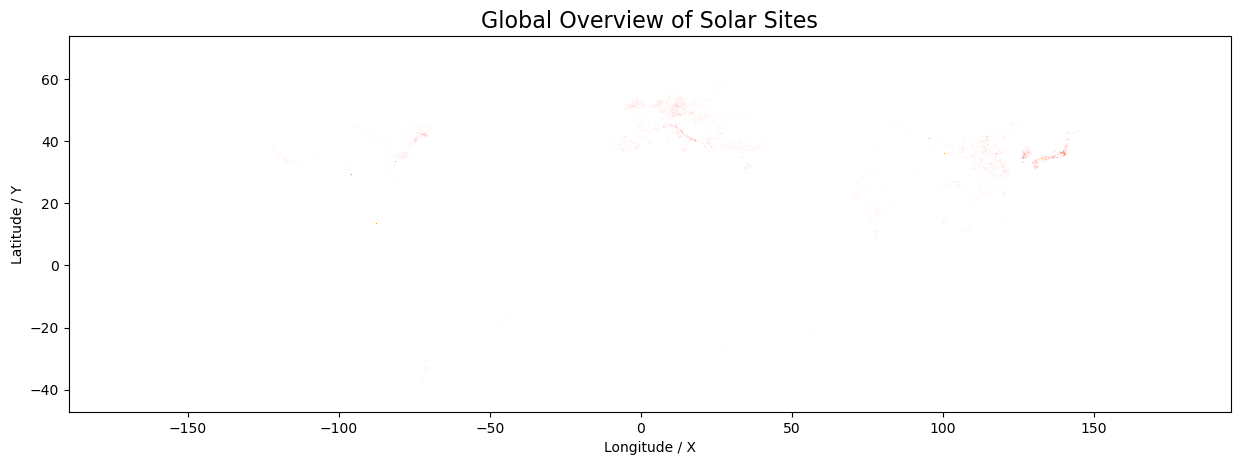

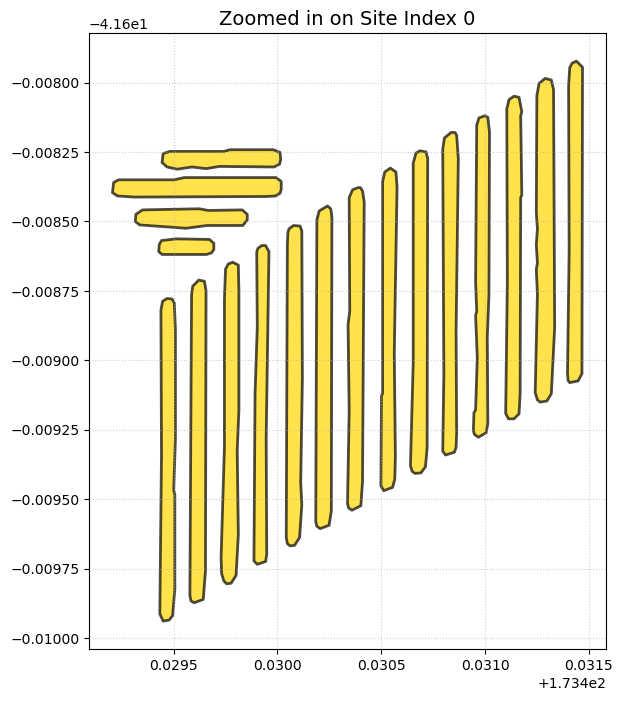

In [5]:
# --- Plot 1: The Global Overview ---
# If your dataset is truly global, this will look like a map of the Earth made of tiny dots.
fig, ax = plt.subplots(figsize=(15, 8))
gdf.plot(ax=ax, color='orange', markersize=1) # using a small markersize if they render as points at this scale
ax.set_title("Global Overview of Solar Sites", fontsize=16)
ax.set_xlabel("Longitude / X")
ax.set_ylabel("Latitude / Y")
plt.show()

# --- Plot 2: Zoom in on a Single Polygon ---
fig, ax = plt.subplots(figsize=(8, 8))

# Let's grab just the very first row (index 0)
first_site = gdf.iloc[[0]] 

# Plot it
first_site.plot(ax=ax, facecolor='gold', edgecolor='black', linewidth=2, alpha=0.7)

# Add some gridlines and a title
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_title(f"Zoomed in on Site Index 0", fontsize=14)
plt.show()

In [61]:
# --- 1. Top 20 Countries ---
print("--- Top 20 Countries by Solar Sites ---")
top_countries = gdf['country'].value_counts().head(20)
print(top_countries)
print("\n")

# --- 2. Create the Subset ---
# Note: Check the output of the Top 20 list to see if the UK is listed as 
# 'UK', 'United Kingdom', or 'Great Britain'. I'm assuming 'United Kingdom' here.
target_countries = ['Spain', 'France', 'United Kingdom', 'Germany']

# We use .copy() to avoid SettingWithCopy warnings later
gdf_europe = gdf[gdf['country'].isin(target_countries)].copy()

print(f"Created subset 'gdf_europe' with {len(gdf_europe)} sites.")
print("\n")

# --- 3. Crucial EDA: The Temporal Reality Check ---
print("--- Installation Year Distribution (Europe Subset) ---")
# This tells us if we have sites built before Sentinel-2 existed (pre-2015)
print(gdf_europe['year'].value_counts().sort_index())
print("\n")

# --- 4. Crucial EDA: The Spatial Reality Check ---
print("--- Area Statistics (m^2) (Europe Subset) ---")
# This helps us decide how large our "fixed size" image patch needs to be
# pandas will suppress scientific notation for readability
with pd.option_context('display.float_format', lambda x: f'{x:,.2f}'):
    print(gdf_europe['area_m2'].describe())
print("\n")

# --- 5. Verify Geometry Types ---
print("--- Geometry Types ---")
# Ensures everything is actually a Polygon/MultiPolygon and not a Point
print(gdf_europe.geom_type.value_counts())

--- Top 20 Countries by Solar Sites ---
country
China                       39945
Japan                       20400
United States of America    15210
Germany                      9719
Italy                        7308
India                        5847
Spain                        5315
South Korea                  5097
Greece                       4819
Turkey                       3315
United Kingdom               2749
France                       2478
Poland                       1839
Hungary                      1257
Czechia                      1119
Brazil                       1100
Netherlands                  1005
Vietnam                       853
Chile                         798
Thailand                      740
Name: count, dtype: int64


Created subset 'gdf_europe' with 20261 sites.


--- Installation Year Distribution (Europe Subset) ---
year
2017    12115
2018      892
2019      907
2020     1205
2021     1321
2022      995
2023     2055
2024      771
Name: count, dtype: int6

## Sentinel-2 Exploration

In [14]:
# 1. Select a test site (Let's pick a nice big one built in 2020)
test_sites = gdf_europe[(gdf_europe['year'] == 2020) & (gdf_europe['area_m2'] > 100000)]
test_site = test_sites.iloc[[0]].copy() # Grab the first one

print(f"Testing on site ID: {test_site['PV_ID'].values[0]} in {test_site['country'].values[0]}")

# 2. The Buffering Magic (Degrees -> Meters -> Degrees)
# EPSG:3857 is Web Mercator (uses meters). It distorts area slightly, but 
# for a 3km buffer bounding box, it's perfectly fine.
test_site_meters = test_site.to_crs(epsg=3857)

# Apply a 3,000 meter (3km) buffer around the actual polygon footprint
buffered_site_meters = test_site_meters.buffer(5000)

# Project the resulting buffered polygon back to EPSG:4326 (Lat/Lon)
buffered_site_4326 = buffered_site_meters.to_crs(epsg=4326)

# Extract the bounding box [min_lon, min_lat, max_lon, max_lat]
bbox = buffered_site_4326.total_bounds
print(f"Buffered Bounding Box: {bbox}")

# 3. Time Travel: Define our "Before" window
# If it was built in 2020, let's look for images from the summer of 2019
# (Summer usually has less snow/clouds and better lighting in Europe)
time_range = "2019-06-01/2019-08-30"

# 4. Querying the STAC API (Earth Search by Element84 is free and hosts Sentinel-2)
print("\nConnecting to STAC API...")
stac_api_url = "https://earth-search.aws.element84.com/v1"
client = Client.open(stac_api_url)

# Run the search
search = client.search(
    collections=["sentinel-2-l2a"], # Level-2A is atmospherically corrected (Surface Reflectance)
    bbox=bbox,
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": 10}} # Less than 10% cloud cover
)

# Convert the results to a list of items
items = list(search.items())
print(f"Found {len(items)} cloud-free Sentinel-2 scenes for this bounding box!")

# Print out the date and cloud cover of the first match
if items:
    first_item = items[0]
    print(f"\nBest match date: {first_item.datetime}")
    print(f"Cloud cover: {first_item.properties['eo:cloud_cover']}%")

Testing on site ID: 71919 in Germany
Buffered Bounding Box: [ 8.9800833  54.19382286  9.08617474 54.25038284]

Connecting to STAC API...
Found 14 cloud-free Sentinel-2 scenes for this bounding box!

Best match date: 2019-08-26 10:45:53.124000+00:00
Cloud cover: 1.567928%


--- FETCHING 'BEFORE' IMAGE (2019) ---
Using 'Before' date: 2019-09-22 10:35:50.108000+00:00

--- FETCHING 'AFTER' IMAGE (2022) ---
Using 'After' date: 2022-08-25 10:46:01.261000+00:00

--- CREATING PLOTS ---


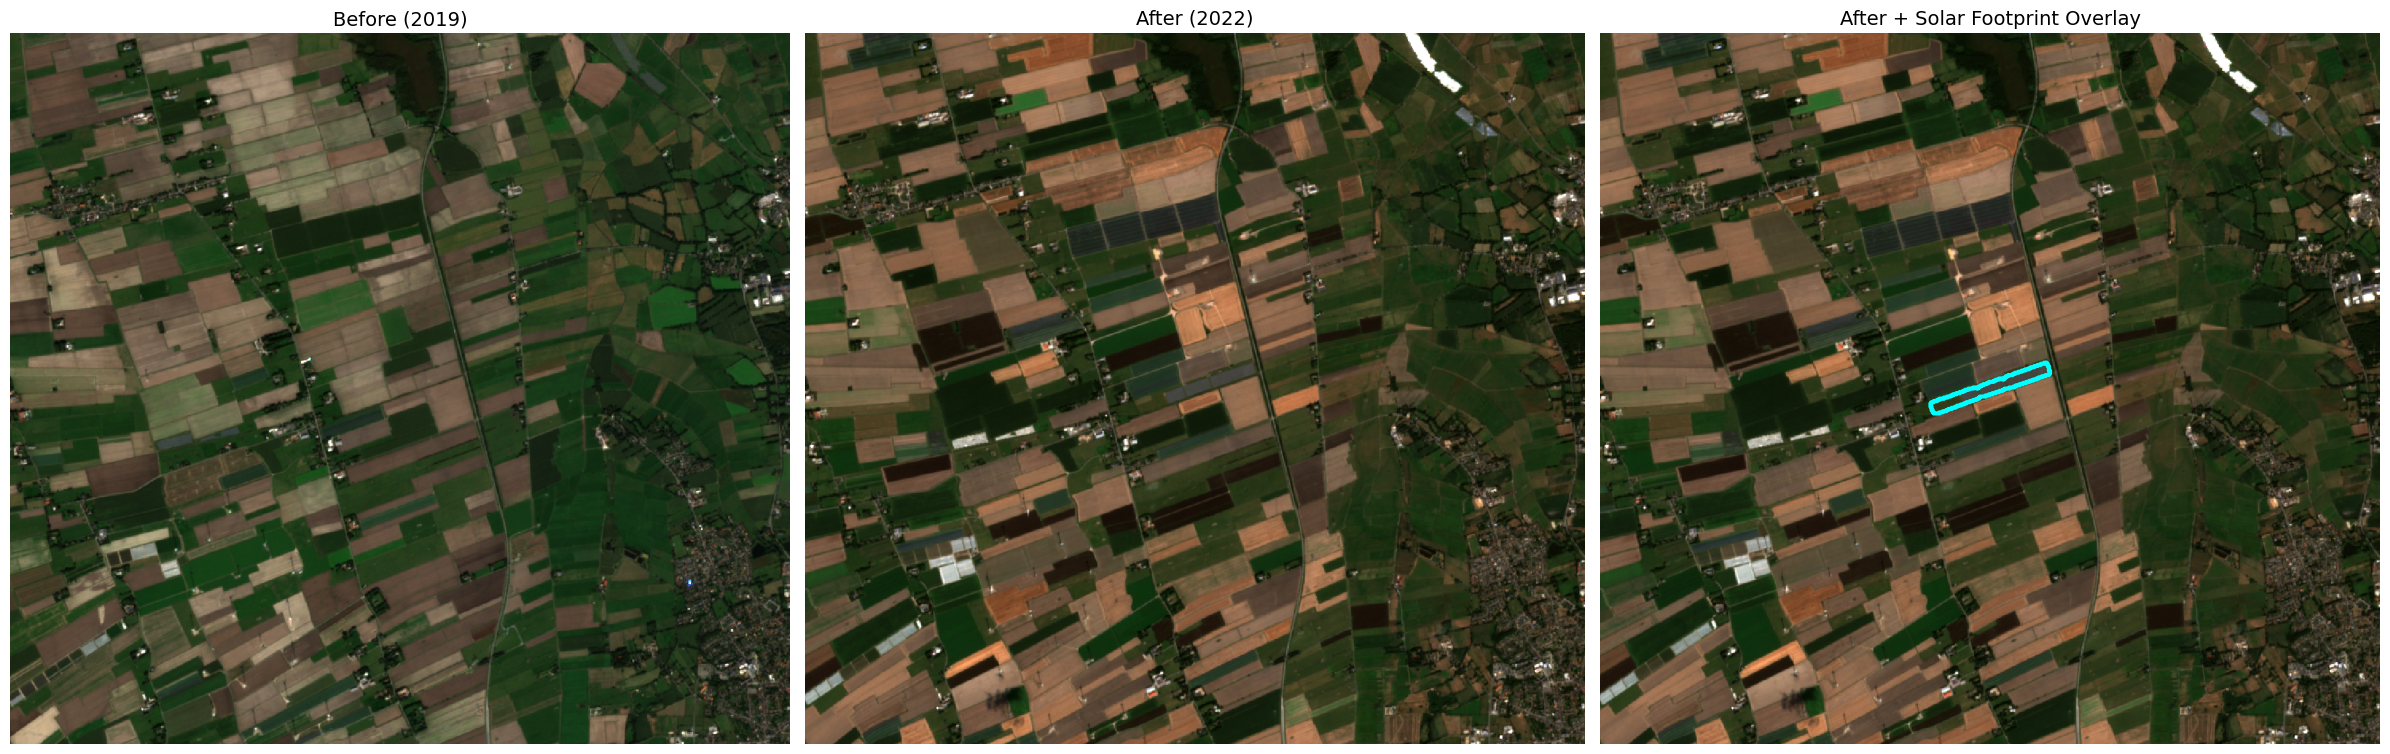

In [9]:

# # --- SETUP (Repeating essential bits from previous step for context) ---
# gpkg_path = "solar_sites.gpkg" 
# gdf = gpd.read_file(gpkg_path)
# gdf_europe = gdf[gdf['country'].isin(['Spain', 'France', 'United Kingdom', 'Germany'])].copy()

# # Re-select our test site (ID: 71919 in Germany, built 2020)
# test_site_id = 71919
# test_site = gdf_europe[gdf_europe['PV_ID'] == test_site_id].copy()

# Buffer and BBOX (same as before)
# test_site_meters = test_site.to_crs(epsg=3857)
# buffered_site_meters = test_site_meters.buffer(3000)
# buffered_site_4326 = buffered_site_meters.to_crs(epsg=4326)
# bbox = buffered_site_4326.total_bounds

# Connect to STAC API
stac_api_url = "https://earth-search.aws.element84.com/v1"
client = Client.open(stac_api_url)

# Define Sentinel-2 RGB bands (True Color)
# These are at 10-meter resolution
assets = ["red", "green", "blue"]

# --- helper function for RGB scaling ---
# Sentinel-2 Level-2A reflectance data ranges from 0 to >10,000.
# We need to scale/clip it to 0-1 for matplotlib.
def scale_rgb(ds, max_val=3000):
    rgb = np.stack([ds.red.values, ds.green.values, ds.blue.values], axis=-1)
    rgb = rgb.astype('float32') / max_val
    rgb = np.clip(rgb, 0, 1)
    return rgb


# ==============================================================================
# 1. DOWNLOAD "BEFORE" IMAGE (Summer 2019)
# ==============================================================================
print("--- FETCHING 'BEFORE' IMAGE (2019) ---")
before_range = "2019-06-01/2019-09-30"

search_before = client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=before_range,
    query={"eo:cloud_cover": {"lt": 5}} # Tighter cloud filter
)
items_before = list(search_before.items())

# Take the absolute best (least cloudy) one
item_before = items_before[0]
print(f"Using 'Before' date: {item_before.datetime}")

ds_before = load([item_before], bands=assets, bbox=bbox, crs="EPSG:3857", resolution=10)
ds_before = ds_before.squeeze() 
rgb_before = scale_rgb(ds_before)


# ==============================================================================
# 2. DOWNLOAD "AFTER" IMAGE (Summer 2022)
# ==============================================================================
print("\n--- FETCHING 'AFTER' IMAGE (2022) ---")
# Using 2022 to give the vegetation around the site time to normalize post-construction
after_range = "2022-06-01/2022-09-30"

search_after = client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=after_range,
    query={"eo:cloud_cover": {"lt": 5}}
)
items_after = list(search_after.items())

if not items_after:
    raise ValueError("No cloud-free images found in 2022 window. Try widening search.")

item_after = items_after[0]
print(f"Using 'After' date: {item_after.datetime}")

ds_after = load([item_after], bands=assets, bbox=bbox, crs="EPSG:3857", resolution=10)
ds_after = ds_after.squeeze()
rgb_after = scale_rgb(ds_after)


# ==============================================================================
# 3. CREATE MASK AND VISUALIZE
# ==============================================================================
print("\n--- CREATING PLOTS ---")

# Calculate the spatial extent of the image so matplotlib knows where it sits in the world
# format: [left, right, bottom, top]
img_extent = [
    ds_after.x.min().item(), ds_after.x.max().item(),
    ds_after.y.min().item(), ds_after.y.max().item()
]

fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# PLOT A: BEFORE
axs[0].imshow(rgb_before, extent=img_extent)
axs[0].set_title(f"Before (2019)", fontsize=14)
axs[0].axis('off')

# PLOT B: AFTER
axs[1].imshow(rgb_after, extent=img_extent)
axs[1].set_title(f"After (2022)", fontsize=14)
axs[1].axis('off')

# PLOT C: AFTER + MASK OVERLAY
axs[2].imshow(rgb_after, extent=img_extent)

# CRITICAL FIX: Project the polygon to EPSG:3857 (meters) to match the new image projection
test_site_3857 = test_site.to_crs(epsg=3857)
test_site_3857.plot(ax=axs[2], facecolor='none', edgecolor='cyan', linewidth=3)

axs[2].set_title("After + Solar Footprint Overlay", fontsize=14)
axs[2].axis('off')

plt.tight_layout()
plt.show()

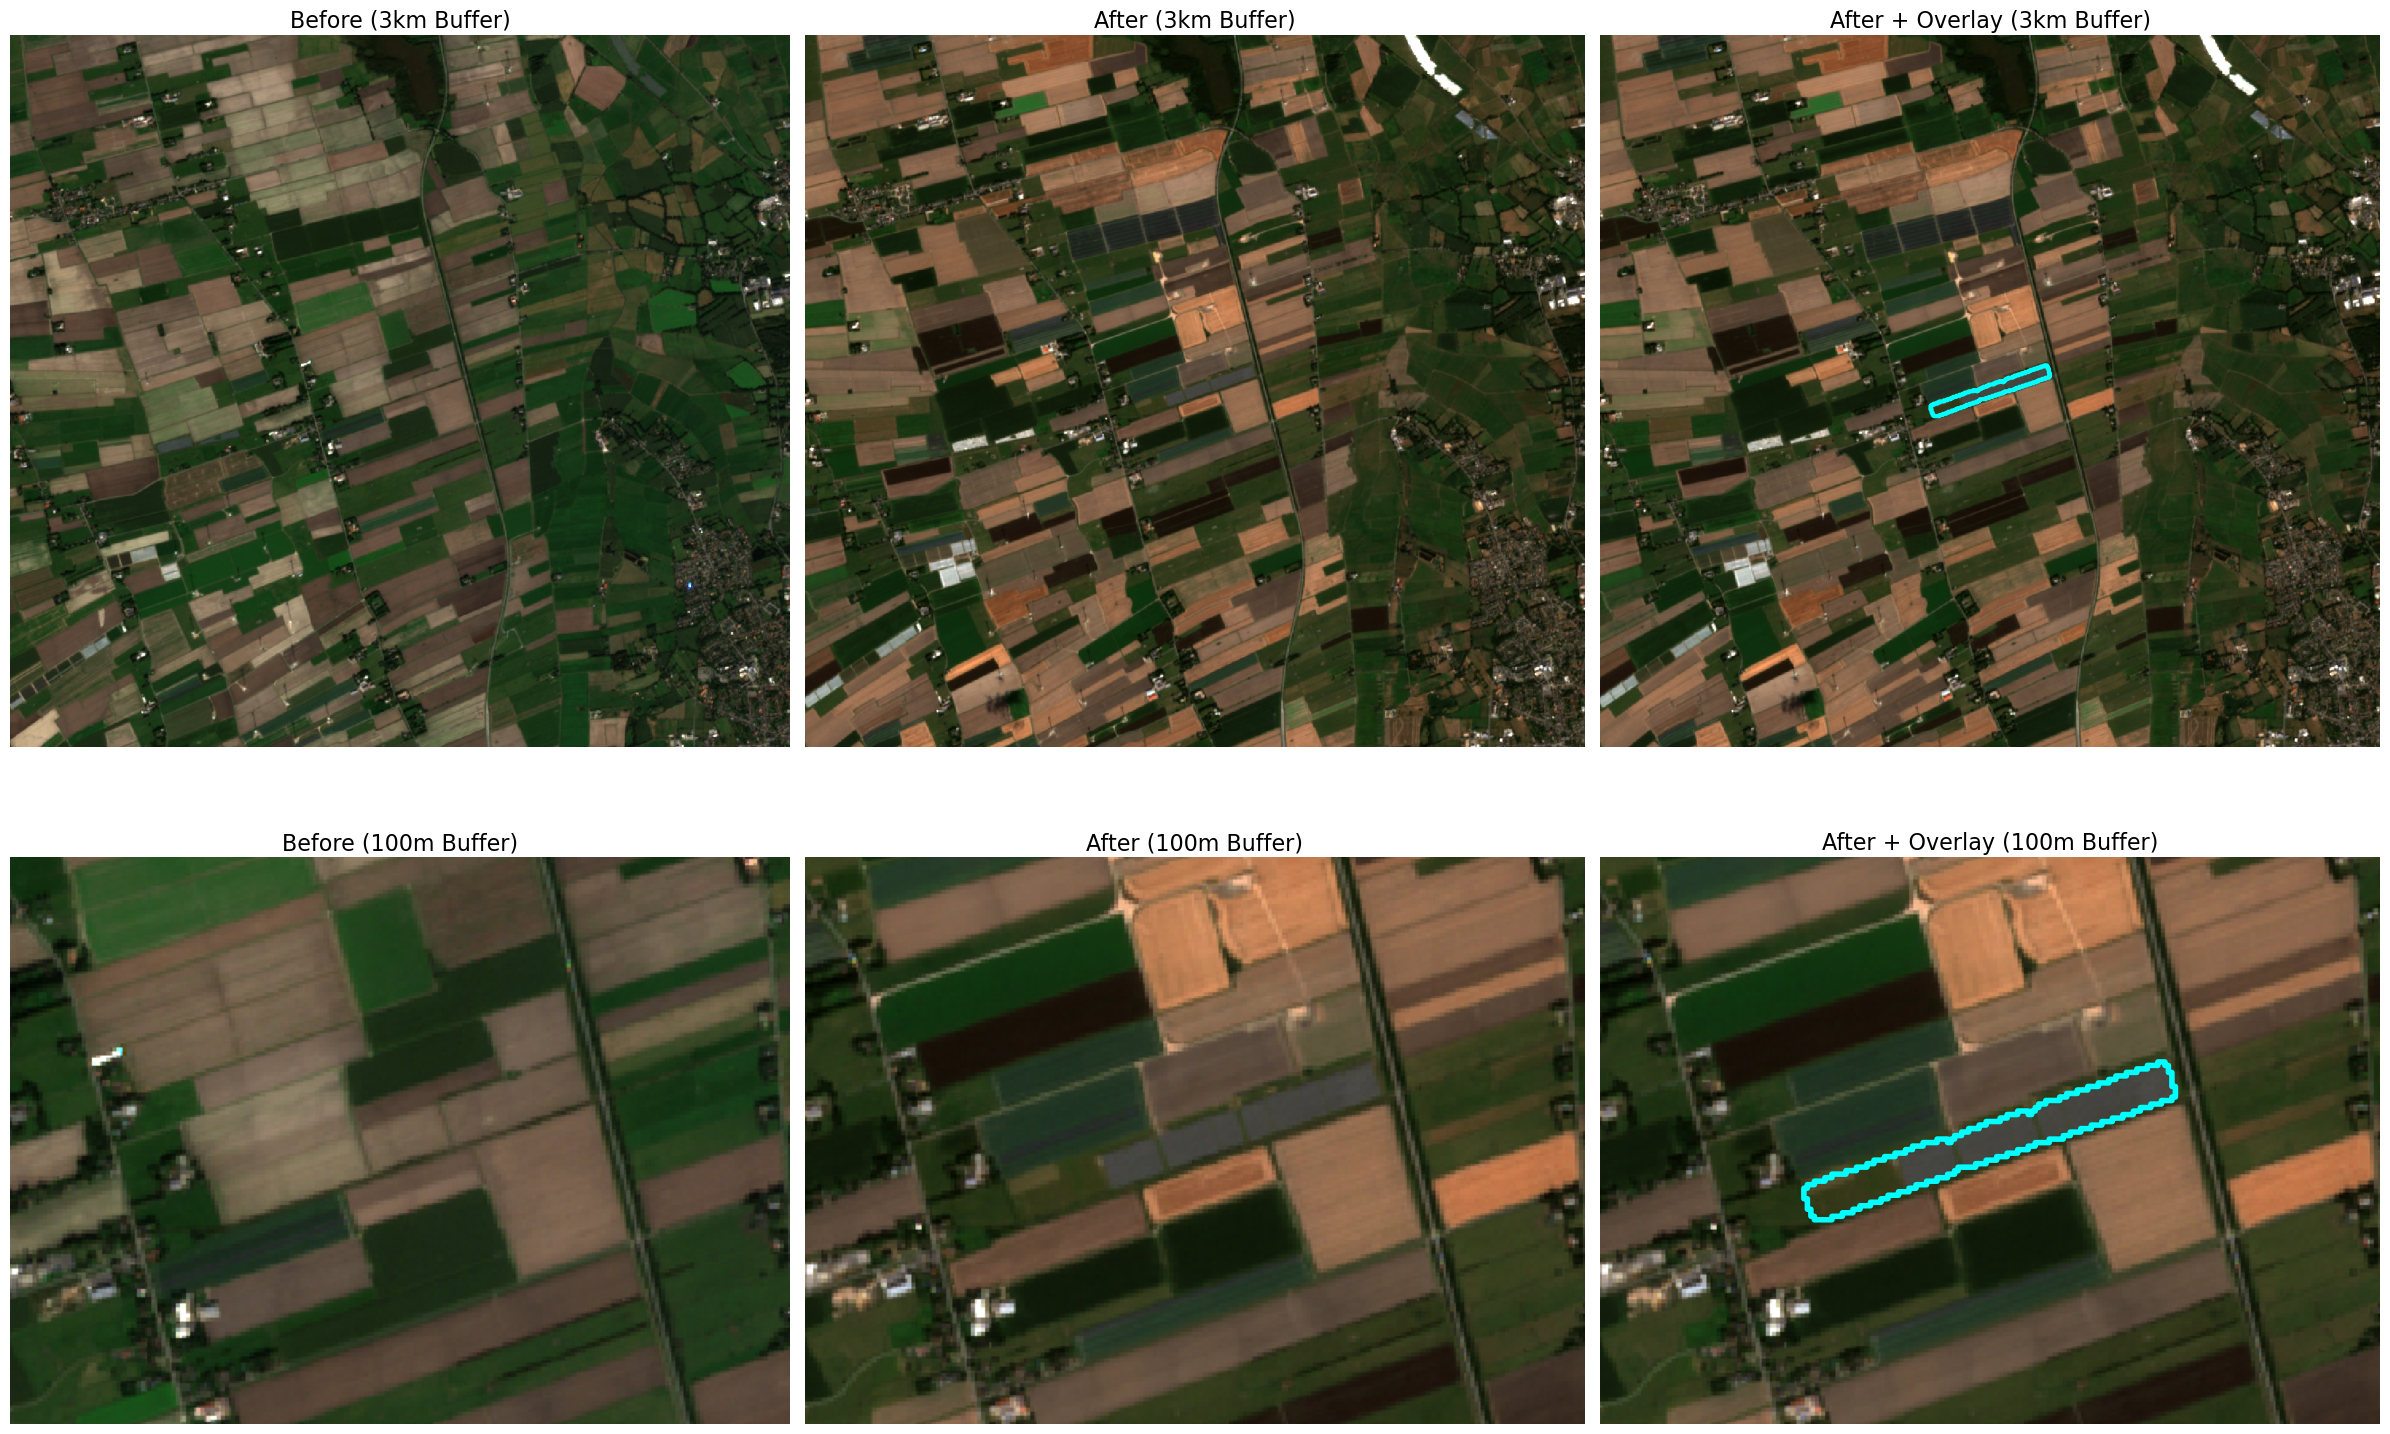

In [10]:
# ==============================================================================
# 1. CALCULATE THE 100m ZOOM BOUNDS
# ==============================================================================
# Create a 100m buffer around the site in our metric projection (EPSG:3857)
test_site_zoom_bounds = test_site_3857.buffer(1000).total_bounds
minx, miny, maxx, maxy = test_site_zoom_bounds

# Slice the existing xarray datasets to these new bounds
# (Note: y is sliced maxy to miny because image coordinates decrease from top to bottom)
ds_before_zoom = ds_before.sel(x=slice(minx, maxx), y=slice(maxy, miny))
ds_after_zoom = ds_after.sel(x=slice(minx, maxx), y=slice(maxy, miny))

# Create our scaled RGB arrays for the zoomed versions
rgb_before_zoom = scale_rgb(ds_before_zoom)
rgb_after_zoom = scale_rgb(ds_after_zoom)

# Get the extent for the zoomed plot so the polygon overlays correctly
img_extent_zoom = [
    ds_after_zoom.x.min().item(), ds_after_zoom.x.max().item(),
    ds_after_zoom.y.min().item(), ds_after_zoom.y.max().item()
]

# ==============================================================================
# 2. CREATE THE 2x3 PLOT
# ==============================================================================
fig, axs = plt.subplots(2, 3, figsize=(24, 16))

# --- ROW 1: THE 3km WIDE VIEW ---
axs[0, 0].imshow(rgb_before, extent=img_extent)
axs[0, 0].set_title("Before (3km Buffer)", fontsize=16)
axs[0, 0].axis('off')

axs[0, 1].imshow(rgb_after, extent=img_extent)
axs[0, 1].set_title("After (3km Buffer)", fontsize=16)
axs[0, 1].axis('off')

axs[0, 2].imshow(rgb_after, extent=img_extent)
test_site_3857.plot(ax=axs[0, 2], facecolor='none', edgecolor='cyan', linewidth=3)
axs[0, 2].set_title("After + Overlay (3km Buffer)", fontsize=16)
axs[0, 2].axis('off')


# --- ROW 2: THE 100m CLOSE-UP ---
axs[1, 0].imshow(rgb_before_zoom, extent=img_extent_zoom)
axs[1, 0].set_title("Before (100m Buffer)", fontsize=16)
axs[1, 0].axis('off')

axs[1, 1].imshow(rgb_after_zoom, extent=img_extent_zoom)
axs[1, 1].set_title("After (100m Buffer)", fontsize=16)
axs[1, 1].axis('off')

axs[1, 2].imshow(rgb_after_zoom, extent=img_extent_zoom)
test_site_3857.plot(ax=axs[1, 2], facecolor='none', edgecolor='cyan', linewidth=4)
axs[1, 2].set_title("After + Overlay (100m Buffer)", fontsize=16)
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()

## GEE Mosaics

In [13]:
# ==============================================================================
# 2. DEFINE THE AREA OF INTEREST (AOI)
# ==============================================================================
# We will use the exact bounding box from our previous German test site.
# GEE expects coordinates in EPSG:4326 [min_lon, min_lat, max_lon, max_lat]
bbox = [8.9800833, 54.19382286, 9.08617474, 54.25038284]

# Convert the raw coordinates into an Earth Engine Geometry object
aoi = ee.Geometry.Rectangle(bbox)

# ==============================================================================
# 3. QUERY THE SENTINEL-2 ARCHIVE (No Compositing Yet)
# ==============================================================================
# COPERNICUS/S2_SR_HARMONIZED is the official Level-2A (Surface Reflectance) dataset
s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(aoi)
                 .filterDate('2019-06-01', '2019-09-30')
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)))

# Let's just grab the very first image in the collection to test the connection
test_image = s2_collection.first()

# ==============================================================================
# 4. CREATE THE INTERACTIVE MAP
# ==============================================================================
# Sentinel-2 bands are B4 (Red), B3 (Green), B2 (Blue). 
# The values go up to ~10,000, so we set a max of 3000 to make it look natural.
vis_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000,
    'gamma': 1.4 # Adds a slight contrast boost
}

# Initialize the geemap widget
Map = geemap.Map()

# Center the map camera exactly on our bounding box
Map.centerObject(aoi, zoom=13)

# Add the satellite image to the map (clipped to our bounding box)
Map.addLayer(test_image.clip(aoi), vis_params, 'Single Raw Image (2019)')

# Add a red outline showing our bounding box footprint
#Map.addLayer(aoi, {'color': 'red', 'fillColor': '00000000'}, '3km Bounding Box')

# Render the map in the output cell
Map

Map(center=[54.22210804053604, 9.033129020003033], controls=(WidgetControl(options=['position', 'transparent_b…

In [16]:
# ==============================================================================
# 1. DEFINE OUR ML BANDS
# ==============================================================================
# We are grabbing the 4x 10m bands and 6x 20m bands. 
ml_bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

# ==============================================================================
# 2. THE CLOUD MASKING FUNCTION
# ==============================================================================
def mask_s2_clouds(image):
    """
    Uses the Sentinel-2 Scene Classification Layer (SCL) to mask out clouds/shadows.
    """
    scl = image.select('SCL')
    
    # SCL Classifications we want to REMOVE:
    # 3: Cloud Shadows
    # 8: Cloud (Medium Probability)
    # 9: Cloud (High Probability)
    # 10: Thin Cirrus
    # 11: Snow / Ice (You don't want snow confusing your ML model's solar panel detection)
    
    # Create a mask where the pixels do NOT equal these bad values
    mask = (scl.neq(3)
            .And(scl.neq(8))
            .And(scl.neq(9))
            .And(scl.neq(10))
            .And(scl.neq(11)))
    
    # Return the image with the bad pixels masked (turned transparent)
    # We also explicitly select only our ML bands and scale the reflectance values
    # from 0-10000 to standard 0-1 float values, which is much better for Neural Networks!
    return image.updateMask(mask).select(ml_bands).divide(10000)

# ==============================================================================
# 3. GENERATE THE COMPOSITE
# ==============================================================================
print("Asking Google's servers to calculate the composite...")

# Take our raw collection from before, map the cloud mask over every single image, 
# and then calculate the median of all the clean pixels.
clean_composite = s2_collection.map(mask_s2_clouds).median()

# ==============================================================================
# 4. VISUALIZE THE RESULT
# ==============================================================================
# Even though the image has 10 bands, we can only look at 3 at a time (RGB)
vis_params_composite = {
    'bands': ['B4', 'B3', 'B2'], # Red, Green, Blue
    'min': 0.0,
    'max': 0.3, # Because we divided by 10000, our max visual range is now roughly 0.3
    'gamma': 1.4
}

# Create a new map to see the difference
Map2 = geemap.Map()
Map2.centerObject(aoi, zoom=13)

# Add our new flawless composite
Map2.addLayer(clean_composite.clip(aoi), vis_params_composite, 'Cloud-Free Median Composite')
#Map2.addLayer(aoi, {'color': 'red', 'fillColor': '00000000'}, '3km Bounding Box')

Map2

Asking Google's servers to calculate the composite...


Map(center=[54.22210804053604, 9.033129020003033], controls=(WidgetControl(options=['position', 'transparent_b…

Generating URL ...
Please wait ...
Data downloaded to /Users/abdullah/Documents/Solar Siting/s2_composite_test.tif
Successfully saved to: /Users/abdullah/Documents/Solar Siting/s2_composite_test.tif

--- TENSOR METADATA ---
Shape: 1182x631 pixels
Number of Bands: 10
Data Type: float32
Coordinate Reference System: EPSG:4326

--- DATA INTEGRITY CHECKS ---
Red Band - Min: 0.0060, Max: 0.5904, Mean: 0.0520
Missing Pixels (Persistent Cloud Cover): 0 out of 745842 (0.00%)


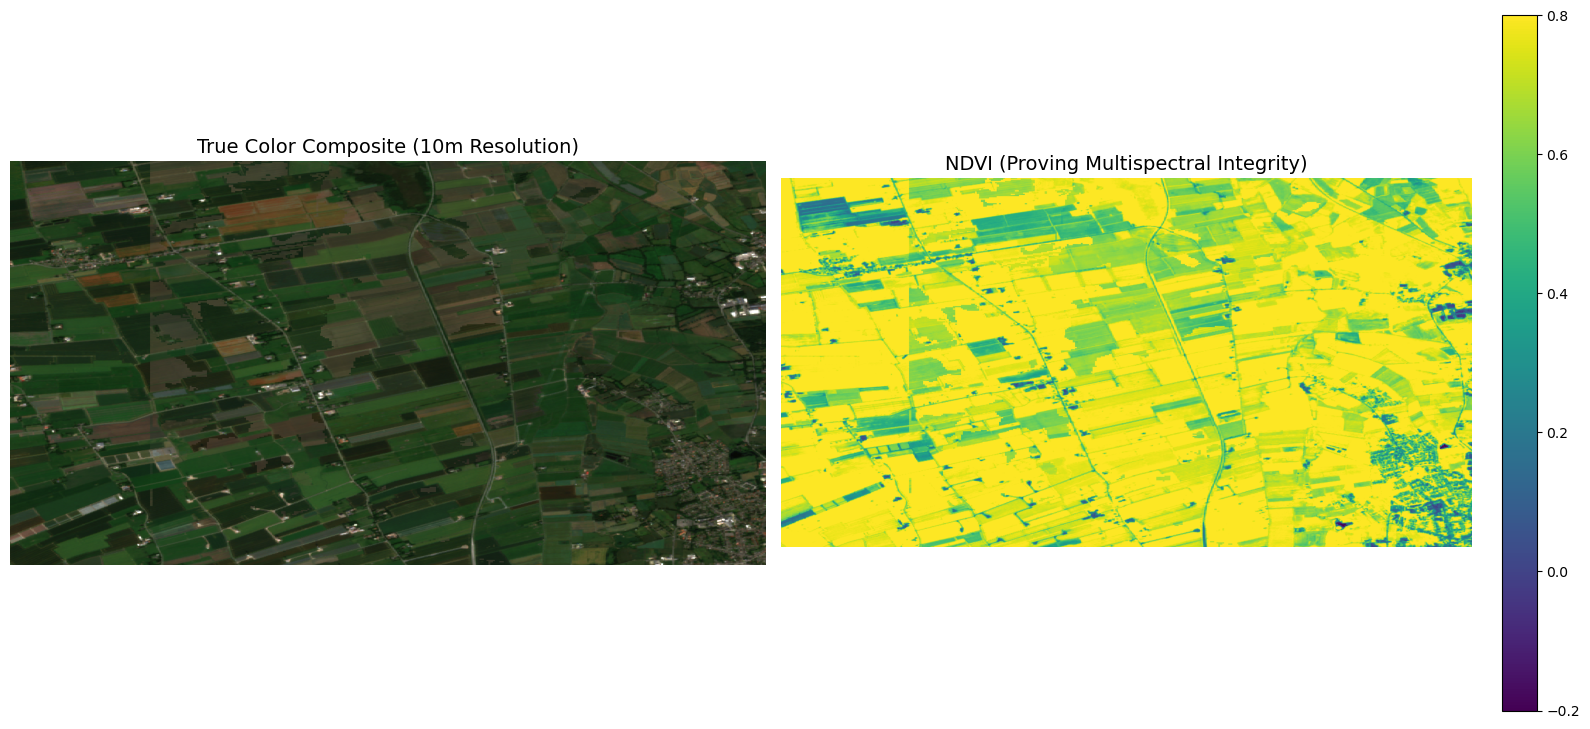

In [18]:

# ==============================================================================
# 1. DOWNLOAD THE TENSOR
# ==============================================================================
print("Downloading 10-band composite from Google Earth Engine...")
out_tif = os.path.join(os.getcwd(), 's2_composite_test.tif')

# This downloads the image directly to your local folder
geemap.ee_export_image(
    clean_composite, 
    filename=out_tif, 
    scale=10,        # Force the calculation at true 10m resolution
    region=aoi,      # Clip exactly to our bounding box
    file_per_band=False # Keep all 10 bands in one file
)
print(f"Successfully saved to: {out_tif}")

# ==============================================================================
# 2. LOAD AND INSPECT WITH RASTERIO
# ==============================================================================
with rasterio.open(out_tif) as src:
    print(f"\n--- TENSOR METADATA ---")
    print(f"Shape: {src.width}x{src.height} pixels")
    print(f"Number of Bands: {src.count}")
    print(f"Data Type: {src.dtypes[0]}")
    print(f"Coordinate Reference System: {src.crs}")
    
    # Rasterio uses 1-based indexing. Based on our ml_bands list:
    # ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    # B4 (Red) is band 3, B3 (Green) is band 2, B2 (Blue) is band 1
    # B8 (Near-Infrared) is band 7
    
    blue = src.read(1)
    green = src.read(2)
    red = src.read(3)
    nir = src.read(7) # We will use this to test multispectral health

# ==============================================================================
# 3. MATHEMATICAL REALITY CHECKS
# ==============================================================================
print(f"\n--- DATA INTEGRITY CHECKS ---")
# Because we divided by 10000 in GEE, max values should generally be under 1.0
print(f"Red Band - Min: {np.nanmin(red):.4f}, Max: {np.nanmax(red):.4f}, Mean: {np.nanmean(red):.4f}")

# Check for "NoData" holes (pixels that were cloudy all summer)
nan_count = np.isnan(red).sum()
total_pixels = red.size
print(f"Missing Pixels (Persistent Cloud Cover): {nan_count} out of {total_pixels} ({(nan_count/total_pixels)*100:.2f}%)")

# ==============================================================================
# 4. VISUALIZE THE TRUE PIXELS
# ==============================================================================
# Create standard RGB (clip to 0.3 for brightness)
rgb = np.dstack((red, green, blue))
rgb_vis = np.clip(rgb / 0.3, 0, 1)

# Calculate NDVI (Normalized Difference Vegetation Index)
# This proves the non-visual 20m/10m bands (like Near-Infrared) downloaded correctly
# NDVI = (NIR - RED) / (NIR + RED)
ndvi = (nir - red) / (nir + red + 1e-8)

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Plot True Color
axs[0].imshow(rgb_vis)
axs[0].set_title("True Color Composite (10m Resolution)", fontsize=14)
axs[0].axis('off')

# Plot NDVI (Vegetation Index)
# High values (green/yellow) = healthy plants, Low values (dark purple) = dirt/roads/solar panels
im = axs[1].imshow(ndvi, cmap='viridis', vmin=-0.2, vmax=0.8)
axs[1].set_title("NDVI (Proving Multispectral Integrity)", fontsize=14)
axs[1].axis('off')
plt.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Affine Transform: | 0.00, 0.00, 8.98|
| 0.00,-0.00, 54.25|
| 0.00, 0.00, 1.00|
Center Pixel Coordinates: Longitude: 9.033144, Latitude: 54.222086


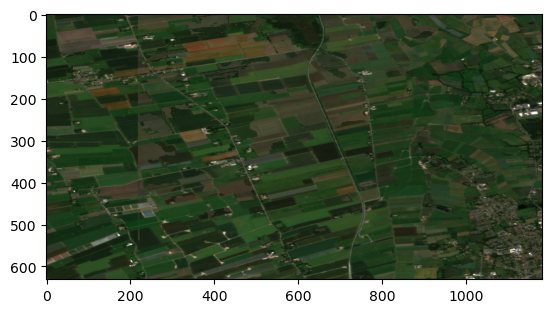

In [60]:
out_tif = os.path.join(os.getcwd(), 's2_composite_test.tif')
with rasterio.open(out_tif) as src:
    # Read the metadata of the first band to get the geotransform
    transform = src.transform
    print(f"Affine Transform: {transform}")
    
    # Calculate the coordinates of the center pixel
    center_x = src.width // 2
    center_y = src.height // 2
    center_lon, center_lat = rasterio.transform.xy(transform, center_y, center_x)
    
    print(f"Center Pixel Coordinates: Longitude: {center_lon:.6f}, Latitude: {center_lat:.6f}")

    blue = src.read(1)
    green = src.read(2)
    red = src.read(3)

    rgb = np.dstack((red, green, blue))
    rgb_vis = np.clip(rgb / 0.3, 0, 1)

    plt.imshow(rgb_vis)
    

## AlphaEarth Embeddings

In [75]:


# ==============================================================================
# 1. SETUP THE AREA OF INTEREST & EXACT FOOTPRINT
# ==============================================================================
print("Setting up geometries...")
# Grab our German test site built in 2020
test_site = gdf_europe[(gdf_europe['year'] == 2020) & (gdf_europe['area_m2'] > 100000)].iloc[[0]].copy()

# Create the 3km Bounding Box for the clipping extent
test_site_3857 = test_site.to_crs(epsg=3857)
bbox_3857 = test_site_3857.buffer(3000).total_bounds 
bbox_4326 = gpd.GeoSeries([geometry.box(*bbox_3857)], crs=3857).to_crs(epsg=4326).total_bounds
aoi = ee.Geometry.Rectangle(list(bbox_4326))

# Create the exact Earth Engine footprint for the high-vis overlay
test_site_4326 = test_site.to_crs(epsg=4326)
site_ee = geemap.geopandas_to_ee(test_site_4326)

# ==============================================================================
# 2. QUERY THE ALPHAEARTH EMBEDDINGS
# ==============================================================================
print("Querying Google AlphaEarth Annual Embeddings...")
embedding_collection = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')

emb_2018 = (embedding_collection
            .filterDate('2018-01-01', '2018-12-31')
            .filterBounds(aoi)
            .mosaic())

emb_2022 = (embedding_collection
            .filterDate('2022-01-01', '2022-12-31')
            .filterBounds(aoi)
            .mosaic())

# ==============================================================================
# 3. CALCULATE COSINE SIMILARITY (DOT PRODUCT)
# ==============================================================================
print("Calculating Cosine Similarity (Dot Product)...")
similarity_img = emb_2018.multiply(emb_2022).reduce(ee.Reducer.sum())

# ==============================================================================
# 4. VISUALIZATION & MAP SETUP
# ==============================================================================
# Vis params for the raw embeddings (Widened slightly from -0.3 to -1.0 to prevent total blowout, 
# but feel free to change back to -0.3 if you prefer the neon look!)
vis_params_emb = {
    'bands': ['A01', 'A16', 'A09'], 
    'min': -0.3, 
    'max': 0.3
}

# Vis params for the similarity map
vis_params_sim = {
    'min': 0.0,
    'max': 1.0,
    'palette': ['white', 'black'] # Brighter white = High Change (Solar Site Built)
}

# Create the master map
Map = geemap.Map()
Map.centerObject(site_ee, zoom=14)

# Add the layers sequentially. 
# We pass 'False' to the first two so they don't visually overlap the similarity map on load.
# You can turn them on via the Layer Control in the top right corner!
Map.addLayer(emb_2018.clip(aoi), vis_params_emb, '1. Embeddings 2018 (Before)', False)
Map.addLayer(emb_2022.clip(aoi), vis_params_emb, '2. Embeddings 2022 (After)', False)
Map.addLayer(similarity_img.clip(aoi), vis_params_sim, '3. Similarity Difference (22 minus 18)', True)

# Add the EXACT outline of the solar site on top of everything
outline_style = {'color': '00FFFF', 'fillColor': '00000000', 'width': 3}
Map.addLayer(site_ee.style(**outline_style), {}, 'Exact Solar Footprint')

# Display the map
Map

Setting up geometries...
Querying Google AlphaEarth Annual Embeddings...
Calculating Cosine Similarity (Dot Product)...


Map(center=[54.22208243466757, 9.033134061760839], controls=(WidgetControl(options=['position', 'transparent_b…

## Model Training

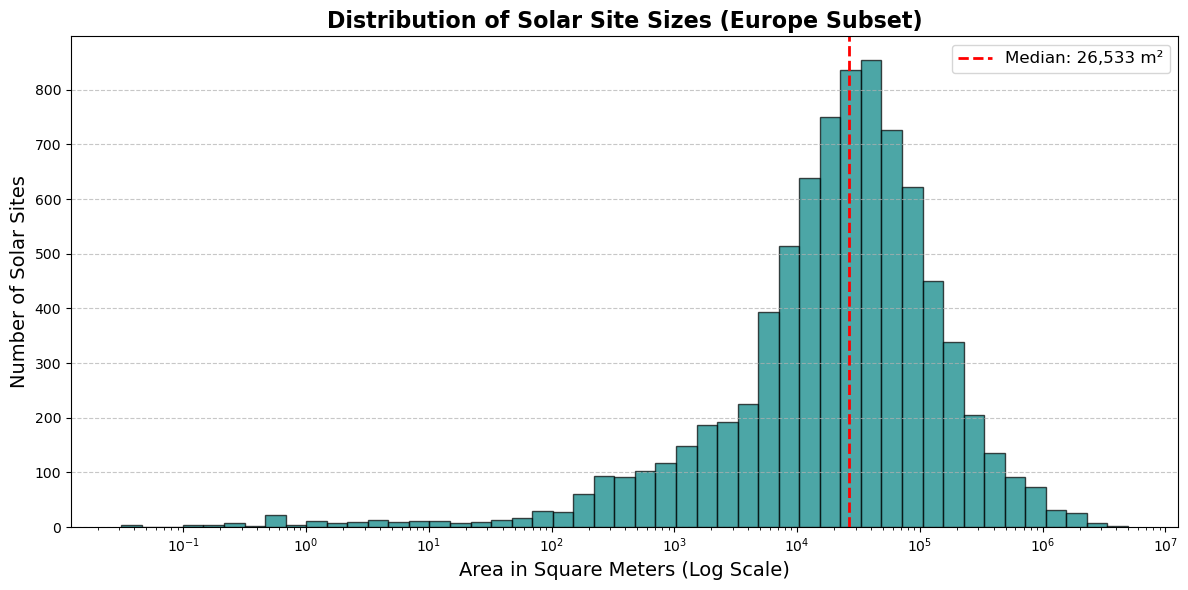

In [68]:
# Set up a nice, wide figure
fig, ax = plt.subplots(figsize=(12, 6))

# Filter out any zero or negative areas just to be safe (since log(0) is undefined)
valid_areas = gdf_europe[gdf_europe['area_m2'] > 0]['area_m2']

# Create 50 logarithmic bins between our minimum and maximum area
bins = np.logspace(np.log10(valid_areas.min()), np.log10(valid_areas.max()), 50)

# Plot the histogram
ax.hist(valid_areas, bins=bins, color='teal', edgecolor='black', alpha=0.7)

# Force the x-axis to display in log scale
ax.set_xscale('log')

# Add descriptive labels and title
ax.set_title('Distribution of Solar Site Sizes (Europe Subset)', fontsize=16, fontweight='bold')
ax.set_xlabel('Area in Square Meters (Log Scale)', fontsize=14)
ax.set_ylabel('Number of Solar Sites', fontsize=14)

# Add a vertical line for our median size to help orient the eye
median_area = valid_areas.median()
ax.axvline(median_area, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_area:,.0f} m²')

ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

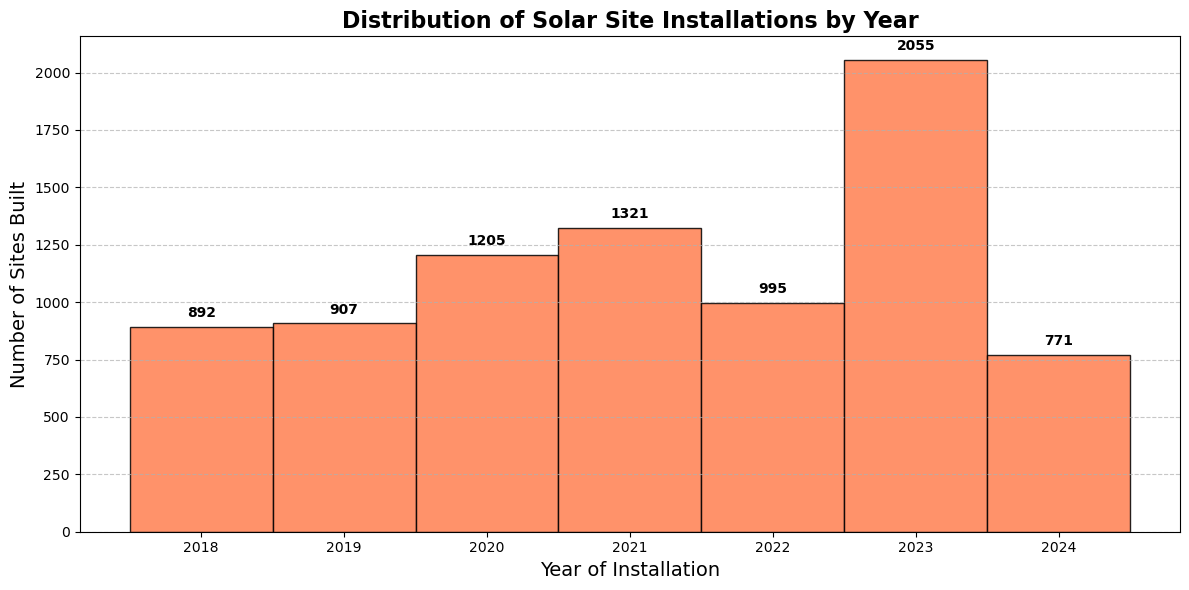

In [69]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

# Grab the year data, dropping any accidental NaNs
years = gdf_europe['year'].dropna().astype(int)

# Create bins for every single year from the minimum to the maximum
min_year, max_year = years.min(), years.max()
bins = np.arange(min_year, max_year + 2) - 0.5 # -0.5 centers the bars on the tick marks

# Plot the histogram
counts, _, patches = ax.hist(years, bins=bins, color='coral', edgecolor='black', alpha=0.85)

# Formatting
ax.set_title('Distribution of Solar Site Installations by Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year of Installation', fontsize=14)
ax.set_ylabel('Number of Sites Built', fontsize=14)

# Force the X-axis to show every single year clearly
ax.set_xticks(range(min_year, max_year + 1))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar for easy reading
for count, patch in zip(counts, patches):
    if count > 0:
        ax.annotate(f'{int(count)}', 
                    xy=(patch.get_x() + patch.get_width() / 2, count),
                    xytext=(0, 5), # 5 points vertical offset
                    textcoords='offset points',
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [67]:
# ==============================================================================
# FILTER BY YEAR (PREDICTIVE MODELING REQUIREMENT)
# ==============================================================================
# The earliest AlphaEarth embedding is 2017. 
# Therefore, any site built before 2018 cannot have a "before" image.
original_count = len(gdf_europe)
gdf_europe = gdf_europe[gdf_europe['year'] >= 2018].copy()

print(f"Dropped {original_count - len(gdf_europe)} sites built before 2018.")
print(f"Remaining valid sites for predictive modeling: {len(gdf_europe)}")

Dropped 12115 sites built before 2018.
Remaining valid sites for predictive modeling: 8146


Total sites over 10,000 m^2: 5845
Dataset split -> Train: 1000 | Validation: 200 | Test: 200
426.73255490418524
263.4651921875775
545.2219247771427
567.3942872760817
1000.6314575603465
654.8518229750916
242.52558583486825
329.7930760260206
704.1164328679442
948.5162724927068
516.1128538297489
887.1191067202017
407.240413923515
567.8700050623156
725.8740091294749
360.72293418546906
622.3979101567529
2051.3298703748733
544.9143123047252
889.7575057474896
467.96380812022835
488.2876073336229
286.75220408910536
403.5467435158789
265.2107536831172
438.3894341289997
559.5637986874208
260.3272855794057
347.76663788594306
354.6953403742518
740.5359533964584
721.6144464574754
707.0496601997875
216.15820800885558
319.5329589645844
263.24138735141605
664.655445211567
231.10229721909855
1674.3703426206484
574.83195398096
330.4961634835872
201.59100185990246
587.8886199551634
635.8417396612931
665.5394729143009
258.164652698586
574.7346885195002
873.1555453436449
300.2762678137515
1605.166971613944

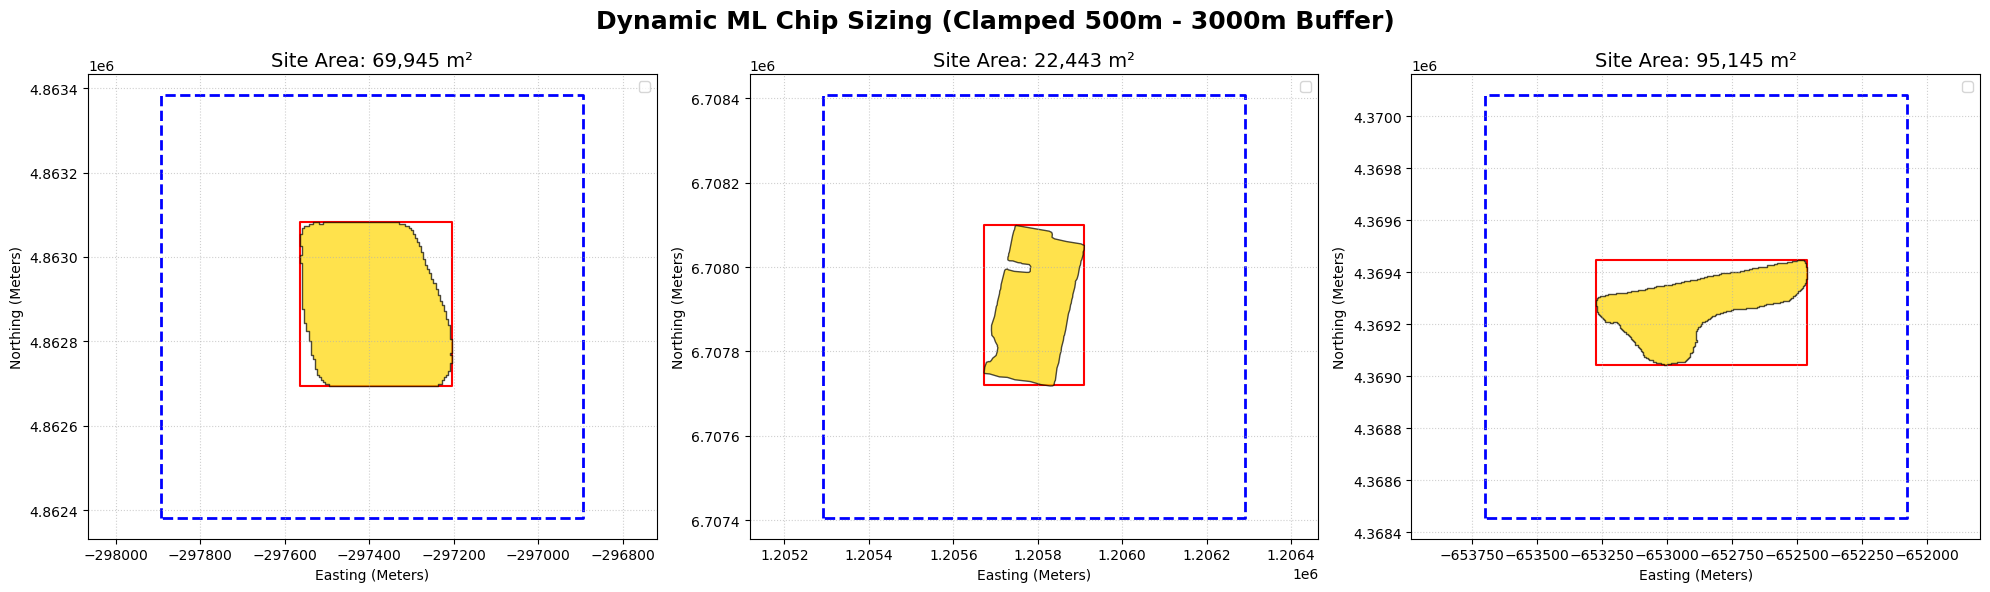

In [43]:


# ==============================================================================
# 1. FILTER AND SPLIT THE DATASET
# ==============================================================================
# Filter out sites smaller than 10,000 m^2
gdf_filtered = gdf_europe[gdf_europe['area_m2'] >= 10000].copy()
print(f"Total sites over 10,000 m^2: {len(gdf_filtered)}")

# Create the Train (1000), Val (200), Test (200) splits
# We use a random_state for reproducibility
train_df, temp_df = train_test_split(gdf_filtered, train_size=1000, random_state=42)
val_df, test_df = train_test_split(temp_df, train_size=200, test_size=200, random_state=42)

print(f"Dataset split -> Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

# ==============================================================================
# 2. CALCULATE THE DYNAMIC ML BOUNDING BOXES
# ==============================================================================
# We MUST work in a metric projection (EPSG:3857) to measure meters accurately
gdf_train = train_df.to_crs(epsg=3857).copy()

def calculate_ml_bbox(geom):
    # 1. Get the original physical bounds of the polygon
    minx, miny, maxx, maxy = geom.bounds
    
    # 2. Find the longest axis (width or height)
    width = maxx - minx
    height = maxy - miny
    longest_axis = max(width, height)
    print(longest_axis)
    
    # 3. Clamp the value between 500m and 3000m
    buffer_dist = max(500, min(longest_axis, 3000))
    
    # 4. Create a perfect square box around the centroid using the buffer distance
    # .envelope converts the circular buffer into a square bounding box
    ml_square = geom.centroid.buffer(buffer_dist).envelope
    return ml_square

# Apply the function to create a new geometry column for our ML chips
gdf_train['ml_bbox'] = gdf_train['geometry'].apply(calculate_ml_bbox)

# ==============================================================================
# 3. VISUALIZE THE RESULTS
# ==============================================================================
# Let's pick 3 random sites of different sizes to see how the logic scales
sample_sites = gdf_train.sample(3, random_state=14)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

for ax, (_, row) in zip(axs, sample_sites.iterrows()):
    # Create GeoSeries for easy plotting
    poly_geom = gpd.GeoSeries([row['geometry']])
    ml_bbox_geom = gpd.GeoSeries([row['ml_bbox']])
    
    # Recreate the original tight bounding box just for visualization
    orig_bbox_geom = gpd.GeoSeries([box(*row['geometry'].bounds)])
    
    # Plot 1: The New Dynamic ML Bounding Box (Our export chip size)
    ml_bbox_geom.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2, linestyle='--', label='ML Chip Box')
    
    # Plot 2: The Original Tight Bounding Box
    orig_bbox_geom.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5, label='Original BBox')
    
    # Plot 3: The Actual Solar Polygon
    poly_geom.plot(ax=ax, facecolor='gold', edgecolor='black', alpha=0.7, label='Solar Site')
    
    # Formatting
    ax.set_title(f"Site Area: {row['area_m2']:,.0f} m²", fontsize=14)
    ax.set_xlabel("Easting (Meters)")
    ax.set_ylabel("Northing (Meters)")
    
    # Force axes to be equal so our squares actually look square!
    ax.axis('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')

plt.suptitle("Dynamic ML Chip Sizing (Clamped 500m - 3000m Buffer)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

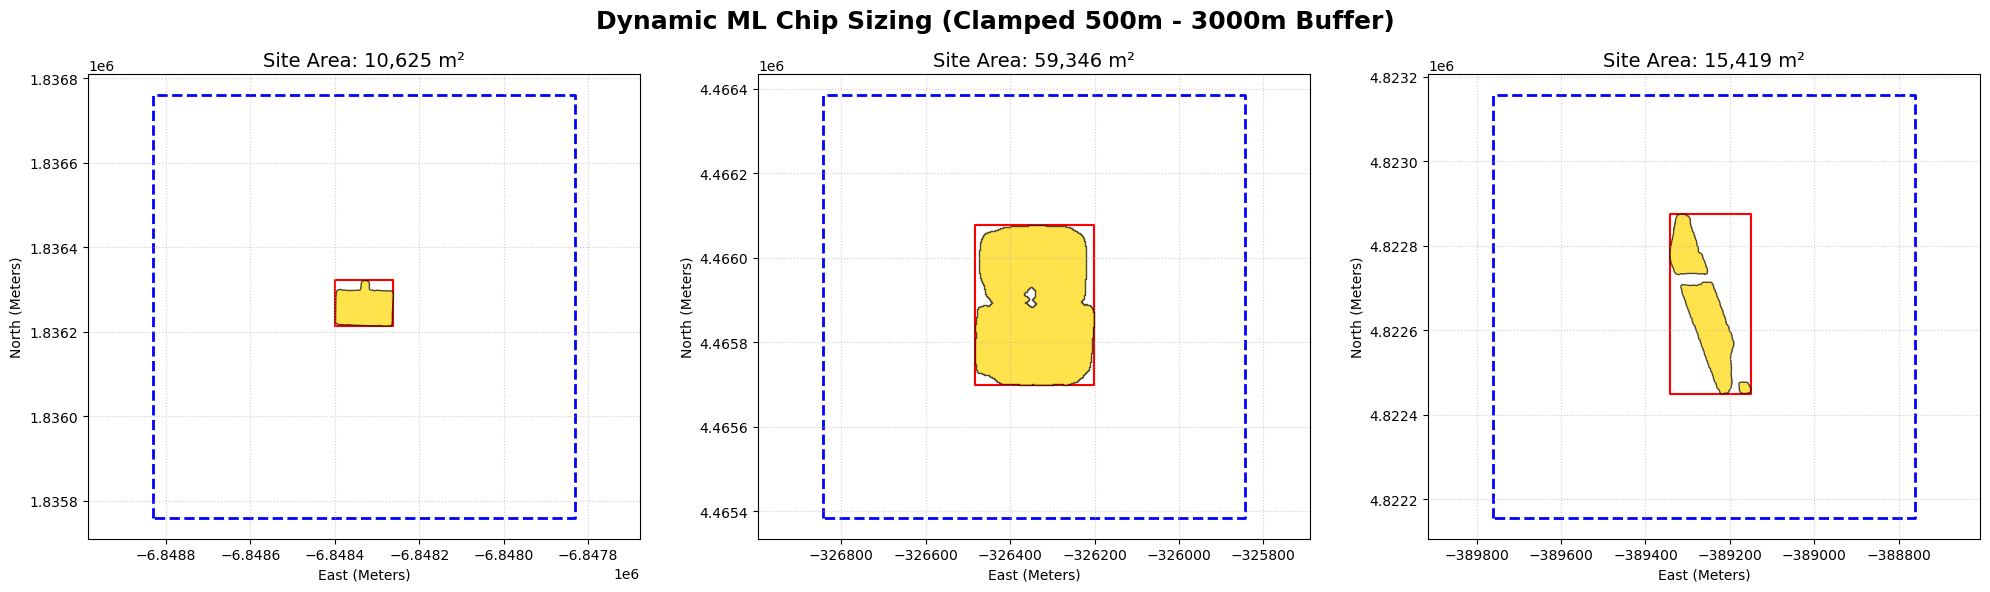

In [84]:
sample_sites = gdf_train.sample(3, random_state=48)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

for ax, (_, row) in zip(axs, sample_sites.iterrows()):
    # Create GeoSeries for easy plotting
    poly_geom = gpd.GeoSeries([row['geometry']])
    ml_bbox_geom = gpd.GeoSeries([row['ml_bbox']])
    
    # Recreate the original tight bounding box just for visualization
    orig_bbox_geom = gpd.GeoSeries([box(*row['geometry'].bounds)])
    
    # Plot 1: The New Dynamic ML Bounding Box (Our export chip size)
    ml_bbox_geom.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2, linestyle='--', label='ML Chip Box')
    
    # Plot 2: The Original Tight Bounding Box
    orig_bbox_geom.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5, label='Original BBox')
    
    # Plot 3: The Actual Solar Polygon
    poly_geom.plot(ax=ax, facecolor='gold', edgecolor='black', alpha=0.7, label='Solar Site')
    
    # Formatting
    ax.set_title(f"Site Area: {row['area_m2']:,.0f} m²", fontsize=14)
    ax.set_xlabel("East (Meters)")
    ax.set_ylabel("North (Meters)")
    
    # Force axes to be equal so our squares actually look square!
    ax.axis('equal')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Dynamic ML Chip Sizing (Clamped 500m - 3000m Buffer)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# ==============================================================================
# PREPARE EXPORT METADATA & GUARDRAILS
# ==============================================================================
# 1. Calculate the target year (Year built - 2, floored at 2017)
# Example: Built 2020 -> Target 2018. Built 2018 -> Target 2017.
gdf_train['target_year'] = (gdf_train['year'] - 2).clip(lower=2017)

# 2. Generate the exact filename Earth Engine will use
gdf_train['export_filename'] = 'solar_alpha_' + gdf_train['PV_ID'].astype(str) + '_' + gdf_train['target_year'].astype(str)

# 3. Initialize the exported flag
gdf_train['exported'] = False



# Sanity check
total_sites = len(gdf_train)

print(f"--- EXPORT STATUS ---")
print(f"Total Training Sites: {total_sites}")

# Check the math on a few rows to ensure the back-dating worked
print("\nSample Date Math Verification:")
print(gdf_train[['PV_ID', 'year', 'target_year', 'export_filename']].head(5))

--- EXPORT STATUS ---
Total Training Sites: 1000

Sample Date Math Verification:
         PV_ID  year  target_year          export_filename
93842    93843  2020         2018   solar_alpha_93843_2018
85284    85285  2019         2017   solar_alpha_85285_2017
92654    92655  2021         2019   solar_alpha_92655_2019
77185    77186  2022         2020   solar_alpha_77186_2020
118465  118466  2023         2021  solar_alpha_118466_2021


In [45]:
#CAUTION: EXPORTS TO GDRIVE

print("Preparing Google Earth Engine Export Tasks...")

# Filter the dataframe to ONLY include sites that haven't been exported yet
sites_to_export = gdf_train[gdf_train['exported'] == False]
print(f"Found {len(sites_to_export)} sites left to export. Starting queue...\n")

embedding_collection = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')

for index, row in sites_to_export.iterrows():
    try:
        # Read the pre-calculated year and filename directly from the dataset
        target_year = row['target_year']
        filename = row['export_filename']
        
        site_emb = (embedding_collection
                    .filterDate(f'{target_year}-01-01', f'{target_year}-12-31')
                    .mosaic())
        
        bbox_4326 = gpd.GeoSeries([row['ml_bbox']], crs=3857).to_crs(epsg=4326).total_bounds
        ee_bounds = ee.Geometry.Rectangle(list(bbox_4326))
        
        task = ee.batch.Export.image.toDrive(
            image=site_emb,
            description=filename, 
            folder="Solar_AlphaEarth_Raw", 
            region=ee_bounds,
            scale=10,            
            crs='EPSG:3857',     
            maxPixels=1e8
        )
        
        task.start()
        print(f"Queued: {filename}")
        
        # Update the dataframe in memory so we know it was queued
        gdf_train.at[index, 'exported'] = True
        
    except Exception as e:
        print(f"FAILED to queue Site ID {row['PV_ID']}: {e}")

print("\nAll tasks queued successfully!")

Preparing Google Earth Engine Export Tasks...
Found 1000 sites left to export. Starting queue...

Queued: solar_alpha_93843_2018
Queued: solar_alpha_85285_2017
Queued: solar_alpha_92655_2019
Queued: solar_alpha_77186_2020
Queued: solar_alpha_118466_2021
Queued: solar_alpha_77840_2019
Queued: solar_alpha_93688_2017
Queued: solar_alpha_84988_2018
Queued: solar_alpha_73226_2017
Queued: solar_alpha_77138_2020
Queued: solar_alpha_78442_2022
Queued: solar_alpha_73499_2018
Queued: solar_alpha_81365_2021
Queued: solar_alpha_78173_2018
Queued: solar_alpha_93790_2017
Queued: solar_alpha_126581_2020
Queued: solar_alpha_81128_2018
Queued: solar_alpha_118882_2021
Queued: solar_alpha_121097_2019
Queued: solar_alpha_81990_2019
Queued: solar_alpha_120230_2021
Queued: solar_alpha_81169_2021
Queued: solar_alpha_121164_2017
Queued: solar_alpha_127118_2020
Queued: solar_alpha_118450_2018
Queued: solar_alpha_78424_2021
Queued: solar_alpha_82249_2022
Queued: solar_alpha_117600_2021
Queued: solar_alpha_77307

In [78]:
# 1. Convert our secondary bounding box geometry into a text string (WKT)
gdf_train['ml_bbox_wkt'] = gdf_train['ml_bbox'].to_wkt()

# 2. Create a copy for saving where we drop the un-saveable geometry object column
gdf_save = gdf_train.drop(columns=['ml_bbox'])

# 3. Save to GeoJSON!
gdf_save.to_file("training_sites_europe.geojson", driver="GeoJSON")
print("Saved local tracking dataset successfully.")

Saved local tracking dataset successfully.


In [3]:
# 1. Load the dataset
gdf_train = gpd.read_file("training_sites_europe.geojson")

# 2. Convert the WKT text string back into a functional GeoPandas geometry column
gdf_train['ml_bbox'] = gpd.GeoSeries.from_wkt(gdf_train['ml_bbox_wkt'])

print(f"Loaded {len(gdf_train)} sites. Ready to resume!")

Loaded 1000 sites. Ready to resume!


In [ ]:
## 128x128 chips with 25% overlap

from tqdm import tqdm # For a nice progress bar!
from rasterio.features import rasterize

# ==============================================================================
# 1. SETUP DIRECTORIES
# ==============================================================================
# Change this to wherever you actually copied the files on your Mac!
RAW_TIF_DIR = "/Users/abdullah/Google Drive/My Drive/Solar_AlphaEarth_Raw" 
OUT_IMG_DIR = "training_chips/images/"
OUT_MASK_DIR = "training_chips/masks/"

os.makedirs(OUT_IMG_DIR, exist_ok=True)
os.makedirs(OUT_MASK_DIR, exist_ok=True)

# Make sure your gdf_train is in the metric projection to match the GeoTIFFs
gdf_train = gdf_train.to_crs(epsg=3857)

# ==============================================================================
# 2. THE DUAL-SLICER FUNCTION
# ==============================================================================
def slice_and_save(img_array, mask_array, base_filename, chip_size=128, overlap_pct=0.25):
    """Slices both the 64-band image and 1-band mask simultaneously and saves them."""
    height, width, _ = img_array.shape
    stride = int(chip_size * (1 - overlap_pct))
    
    if height < chip_size or width < chip_size:
        print(f"Image too small for slicing: {base_filename} (Size: {width}x{height})")
        return # Skip if somehow too small

    y_starts = list(range(0, height - chip_size + 1, stride))
    if y_starts[-1] + chip_size < height: y_starts.append(height - chip_size) # Snap-to-edge
        
    x_starts = list(range(0, width - chip_size + 1, stride))
    if x_starts[-1] + chip_size < width: x_starts.append(width - chip_size) # Snap-to-edge
        
    chip_count = 0
    for y in y_starts:
        for x in x_starts:
            # Slice both exactly the same way
            img_chip = img_array[y : y+chip_size, x : x+chip_size, :]
            mask_chip = mask_array[y : y+chip_size, x : x+chip_size]
            
            # Save as rapid-loading .npy files
            np.save(os.path.join(OUT_IMG_DIR, f"{base_filename}_chip_{chip_count}.npy"), img_chip)
            np.save(os.path.join(OUT_MASK_DIR, f"{base_filename}_chip_{chip_count}.npy"), mask_chip)
            chip_count += 1

# ==============================================================================
# 3. THE MASTER LOOP
# ==============================================================================
print("Starting Chip Generation Pipeline...")

# Only process rows that we successfully exported
valid_sites = gdf_train[gdf_train['exported'] == True]

for index, row in tqdm(valid_sites.iterrows(), total=len(valid_sites)):
    tif_path = os.path.join(RAW_TIF_DIR, f"{row['export_filename']}.tif")
    
    if not os.path.exists(tif_path):
        continue # Skip if file didn't download properly
        
    with rasterio.open(tif_path) as src:
        # Read image and reshape to (Height, Width, Bands)
        img_array = src.read().transpose(1, 2, 0)
        
        # Get the spatial transform matrix of the image
        transform = src.transform
        out_shape = (src.height, src.width)
        
        # Burn the solar polygon into a binary mask (1 for solar, 0 for background)
        # We pass it as a tuple: (geometry, value_to_burn)
        mask_array = rasterize(
            [(row['geometry'], 1)],
            out_shape=out_shape,
            transform=transform,
            fill=0,
            dtype='uint8'
        )
        
    # Send both to the slicer!
    slice_and_save(img_array, mask_array, row['export_filename'], chip_size=128, overlap_pct=0.25)

print("\nChipping complete! Ready for PyTorch.")

Starting Chip Generation Pipeline...


  0%|          | 1/1000 [00:02<39:30,  2.37s/it]

Image too small for slicing: solar_alpha_93843_2018 (Size: 101x101)
Image too small for slicing: solar_alpha_85285_2017 (Size: 101x101)
Image too small for slicing: solar_alpha_92655_2019 (Size: 110x110)
Image too small for slicing: solar_alpha_77186_2020 (Size: 115x114)


  1%|          | 9/1000 [00:02<03:29,  4.73it/s]

Image too small for slicing: solar_alpha_93688_2017 (Size: 101x101)
Image too small for slicing: solar_alpha_84988_2018 (Size: 101x101)


...

Image too small for slicing: solar_alpha_126421_2020 (Size: 101x101)


 99%|█████████▉| 994/1000 [01:52<00:00, 10.79it/s]

Image too small for slicing: solar_alpha_125222_2017 (Size: 112x113)
Image too small for slicing: solar_alpha_73436_2017 (Size: 101x101)
Image too small for slicing: solar_alpha_118808_2021 (Size: 101x101)
Image too small for slicing: solar_alpha_120376_2022 (Size: 101x101)


100%|██████████| 1000/1000 [01:52<00:00,  8.90it/s]

Image too small for slicing: solar_alpha_124576_2020 (Size: 101x101)
Image too small for slicing: solar_alpha_124810_2020 (Size: 101x101)
Image too small for slicing: solar_alpha_125472_2022 (Size: 101x101)
Image too small for slicing: solar_alpha_76877_2021 (Size: 101x101)

Chipping complete! Ready for PyTorch.


In [6]:
import os
import numpy as np
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
from tqdm import tqdm 

# ==============================================================================
# 1. SETUP DIRECTORIES
# ==============================================================================
RAW_TIF_DIR = "/Users/abdullah/Google Drive/My Drive/Solar_AlphaEarth_Raw" 
OUT_IMG_DIR = "training_chips/images/"
OUT_MASK_DIR = "training_chips/masks/"

os.makedirs(OUT_IMG_DIR, exist_ok=True)
os.makedirs(OUT_MASK_DIR, exist_ok=True)

gdf_train = gdf_train.to_crs(epsg=3857)

# ==============================================================================
# 2. THE 64x64 PURE SLICER
# ==============================================================================
def slice_and_save(img_array, mask_array, base_filename, chip_size=64, overlap_pct=0.25):
    """Slices images into 64x64 chips with zero padding."""
    height, width, _ = img_array.shape
    stride = int(chip_size * (1 - overlap_pct)) # 64 * 0.75 = 48
    
    # Failsafe: If an image is somehow smaller than 64x64, skip it
    if height < chip_size or width < chip_size:
        print(f"Image too small for slicing: {base_filename} (Size: {width}x{height})")
        return 

    y_starts = list(range(0, height - chip_size + 1, stride))
    if y_starts[-1] + chip_size < height: y_starts.append(height - chip_size)
        
    x_starts = list(range(0, width - chip_size + 1, stride))
    if x_starts[-1] + chip_size < width: x_starts.append(width - chip_size)
        
    chip_count = 0
    for y in y_starts:
        for x in x_starts:
            img_chip = img_array[y : y+chip_size, x : x+chip_size, :]
            mask_chip = mask_array[y : y+chip_size, x : x+chip_size]
            
            np.save(os.path.join(OUT_IMG_DIR, f"{base_filename}_chip_{chip_count}.npy"), img_chip)
            np.save(os.path.join(OUT_MASK_DIR, f"{base_filename}_chip_{chip_count}.npy"), mask_chip)
            chip_count += 1

# ==============================================================================
# 3. THE MASTER LOOP
# ==============================================================================
print("Starting 64x64 Chip Generation...")

valid_sites = gdf_train[gdf_train['exported'] == True]

for index, row in tqdm(valid_sites.iterrows(), total=len(valid_sites)):
    tif_path = os.path.join(RAW_TIF_DIR, f"{row['export_filename']}.tif")
    
    if not os.path.exists(tif_path):
        continue 
        
    with rasterio.open(tif_path) as src:
        img_array = src.read().transpose(1, 2, 0)
        transform = src.transform
        out_shape = (src.height, src.width)
        
        mask_array = rasterize(
            [(row['geometry'], 1)],
            out_shape=out_shape,
            transform=transform,
            fill=0,
            dtype='uint8'
        )
        
    # Slicing at 64x64!
    slice_and_save(img_array, mask_array, row['export_filename'], chip_size=64, overlap_pct=0.25)

print("\nChipping complete! Ready for PyTorch.")

Starting 64x64 Chip Generation...


100%|██████████| 1000/1000 [02:03<00:00,  8.10it/s]


Chipping complete! Ready for PyTorch.


In [7]:
import os
import numpy as np
from tqdm import tqdm

MASK_DIR = "training_chips/masks/"
mask_files = [f for f in os.listdir(MASK_DIR) if f.endswith('.npy')]

total_chips = len(mask_files)
positive_chips = 0
total_pixels = 0
solar_pixels = 0

print(f"Analyzing {total_chips} mask chips...")

for f in tqdm(mask_files):
    mask = np.load(os.path.join(MASK_DIR, f))
    
    # Check if there is at least one solar pixel in this chip
    if np.max(mask) > 0:
        positive_chips += 1
        
    # Count pixel-level imbalance
    total_pixels += mask.size
    solar_pixels += np.sum(mask)

negative_chips = total_chips - positive_chips

print("\n--- CHIP-LEVEL IMBALANCE ---")
print(f"Positive Chips (Contains Solar): {positive_chips} ({positive_chips/total_chips*100:.1f}%)")
print(f"Negative Chips (Pure Background): {negative_chips} ({negative_chips/total_chips*100:.1f}%)")

print("\n--- PIXEL-LEVEL IMBALANCE ---")
print(f"Solar Pixels: {solar_pixels/total_pixels*100:.2f}% of all pixels")

Analyzing 12867 mask chips...


100%|██████████| 12867/12867 [00:02<00:00, 5265.01it/s]


--- CHIP-LEVEL IMBALANCE ---
Positive Chips (Contains Solar): 6971 (54.2%)
Negative Chips (Pure Background): 5896 (45.8%)

--- PIXEL-LEVEL IMBALANCE ---
Solar Pixels: 9.53% of all pixels


In [10]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ==============================================================================
# 1. THE DATASET CLASS
# ==============================================================================
class SolarDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Load the raw .npy files
        img_arr = np.load(self.image_paths[idx])
        mask_arr = np.load(self.mask_paths[idx])

        # 2. Axis Swapping: (H, W, C) -> (C, H, W)
        # img_arr is (64, 64, 64). We transpose it to (64, 64, 64).
        img_arr = img_arr.transpose((2, 0, 1))
        
        # 3. Mask Formatting: Masks are currently (64, 64). PyTorch wants an explicit channel dimension: (1, 64, 64)
        mask_arr = np.expand_dims(mask_arr, axis=0)

        # 4. Convert to PyTorch Tensors
        # Using float32 for the image (standard for neural networks) and float32 for the mask (for BCE Loss)
        image_tensor = torch.from_numpy(img_arr).float()
        mask_tensor = torch.from_numpy(mask_arr).float()

        return image_tensor, mask_tensor

# ==============================================================================
# 2. PREPARE THE FILE LISTS & TRAIN/VAL SPLIT
# ==============================================================================
print("Gathering files...")
IMG_DIR = "training_chips/images/"
MASK_DIR = "training_chips/masks/"

# Grab all files and sort them to guarantee the images and masks line up perfectly!
all_images = sorted([os.path.join(IMG_DIR, f) for f in os.listdir(IMG_DIR) if f.endswith('.npy')])
all_masks = sorted([os.path.join(MASK_DIR, f) for f in os.listdir(MASK_DIR) if f.endswith('.npy')])

# Double check that we have pairs
assert len(all_images) == len(all_masks), "Mismatch between number of images and masks!"
print(f"Found {len(all_images)} total chips.")

# Split 80% for Training, 20% for Validation
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_images, all_masks, test_size=0.2, random_state=42
)

# ==============================================================================
# 3. CREATE THE DATALOADERS
# ==============================================================================
# Batch size of 64 is a great starting point for 64x64 chips on an M4 Pro
BATCH_SIZE = 64 

train_dataset = SolarDataset(train_imgs, train_masks)
val_dataset = SolarDataset(val_imgs, val_masks)

# num_workers=4 tells your Mac to use 4 CPU cores to prep the next batch while the GPU processes the current one
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders ready! {len(train_loader)} training batches, {len(val_loader)} validation batches.")

Gathering files...
Found 12867 total chips.
DataLoaders ready! 161 training batches, 41 validation batches.


In [11]:
import segmentation_models_pytorch as smp
import torch

print("Initializing the 64-Channel U-Net...")

# Initialize the model
# We use ResNet34 as the encoder: it's light, incredibly fast, and very accurate.
# in_channels=64 is where the magic happens for AlphaEarth!
model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights=None,           # We can't use ImageNet weights because we have 64 channels, not 3!
    in_channels=64,                 # Our AlphaEarth Embedding dimensions
    classes=1,                      # Binary classification: 1 (Solar) or 0 (Background)
    activation=None                 # We keep raw logits here, and apply Sigmoid inside the loss function for stability
)

# Move the model to your Apple Silicon GPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)

print(f"Model successfully loaded onto: {device}")

# ==============================================================================
# THE SMOKE TEST
# ==============================================================================
# Let's push a single batch through to make sure everything connects mathematically
try:
    test_images, test_masks = next(iter(train_loader))
    test_images = test_images.to(device)
    
    # Run forward pass
    outputs = model(test_images)
    
    print(f"\nSUCCESS! Smoke test passed.")
    print(f"Input batch shape:  {test_images.shape} -> (Batch, Channels, Height, Width)")
    print(f"Output batch shape: {outputs.shape} -> (Batch, Classes, Height, Width)")
    
except Exception as e:
    print(f"\nSmoke test FAILED. Error: {e}")

Initializing the 64-Channel U-Net...
Model successfully loaded onto: mps

SUCCESS! Smoke test passed.
Input batch shape:  torch.Size([64, 64, 64, 64]) -> (Batch, Channels, Height, Width)
Output batch shape: torch.Size([64, 1, 64, 64]) -> (Batch, Classes, Height, Width)


In [12]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from tqdm import tqdm

# ==============================================================================
# 1. SETUP OPTIMIZER & LOSS FUNCTION
# ==============================================================================
# Adam is the standard fast-converging optimizer. A learning rate of 1e-4 is safe.
# Swap Adam for AdamW, and explicitly set the weight_decay (1e-2 is a great default)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# We use the built-in Dice Loss from the SMP library
dice_loss_fn = smp.losses.DiceLoss(mode='binary')
# BCEWithLogits combines a Sigmoid layer and BCE into one, which is mathematically more stable
bce_loss_fn = nn.BCEWithLogitsLoss()

def combined_loss(predictions, targets):
    """Calculates a 50/50 mix of BCE and Dice Loss"""
    # BCE expects raw logits (which our model outputs)
    bce = bce_loss_fn(predictions, targets)
    
    # Dice Loss needs probabilities, so we apply sigmoid first
    dice = dice_loss_fn(torch.sigmoid(predictions), targets)
    
    return bce + dice

# ==============================================================================
# 2. THE TRAINING LOOP
# ==============================================================================
EPOCHS = 20

print(f"Starting Training on {device} for {EPOCHS} Epochs...\n")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train() # Tell the model we are updating weights
    train_loss = 0.0
    
    # tqdm gives us a beautiful progress bar for the batches
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for images, masks in train_bar:
        # Move data to your Apple Silicon GPU
        images = images.to(device)
        masks = masks.to(device)
        
        # 1. Clear old gradients
        optimizer.zero_grad()
        
        # 2. Forward pass (Predict)
        outputs = model(images)
        
        # 3. Calculate Error
        loss = combined_loss(outputs, masks)
        
        # 4. Backward pass (Calculate gradients)
        loss.backward()
        
        # 5. Step optimizer (Update model weights)
        optimizer.step()
        
        train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    model.eval() # Tell the model to freeze weights (no dropout, etc.)
    val_loss = 0.0
    
    # torch.no_grad() disables gradient tracking to save memory and speed up validation
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  ")
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = combined_loss(outputs, masks)
            
            val_loss += loss.item()
            val_bar.set_postfix(loss=loss.item())
            
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"--> Epoch {epoch+1} Results: Train Loss = {avg_train_loss:.4f} | Val Loss = {avg_val_loss:.4f}\n")

# ==============================================================================
# 3. SAVE THE TRAINED MODEL
# ==============================================================================
torch.save(model.state_dict(), "solar_unet_64x64_v1.pth")
print("Training Complete! Model weights saved successfully.")

Starting Training on mps for 20 Epochs...



Epoch 1/20 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  7.66it/s, loss=1.44]


--> Epoch 1 Results: Train Loss = 1.4780 | Val Loss = 1.3317



Epoch 2/20 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  8.00it/s, loss=1.35]


--> Epoch 2 Results: Train Loss = 1.2799 | Val Loss = 1.2479



...

--> Epoch 18 Results: Train Loss = 0.9919 | Val Loss = 1.0500



Epoch 19/20 [Val]  : 100%|██████████| 41/41 [00:04<00:00,  8.27it/s, loss=1.03] 


--> Epoch 19 Results: Train Loss = 0.9810 | Val Loss = 1.0546



Epoch 20/20 [Val]  : 100%|██████████| 41/41 [00:04<00:00,  8.36it/s, loss=1.04] 


--> Epoch 20 Results: Train Loss = 0.9739 | Val Loss = 1.0527

Training Complete! Model weights saved successfully.


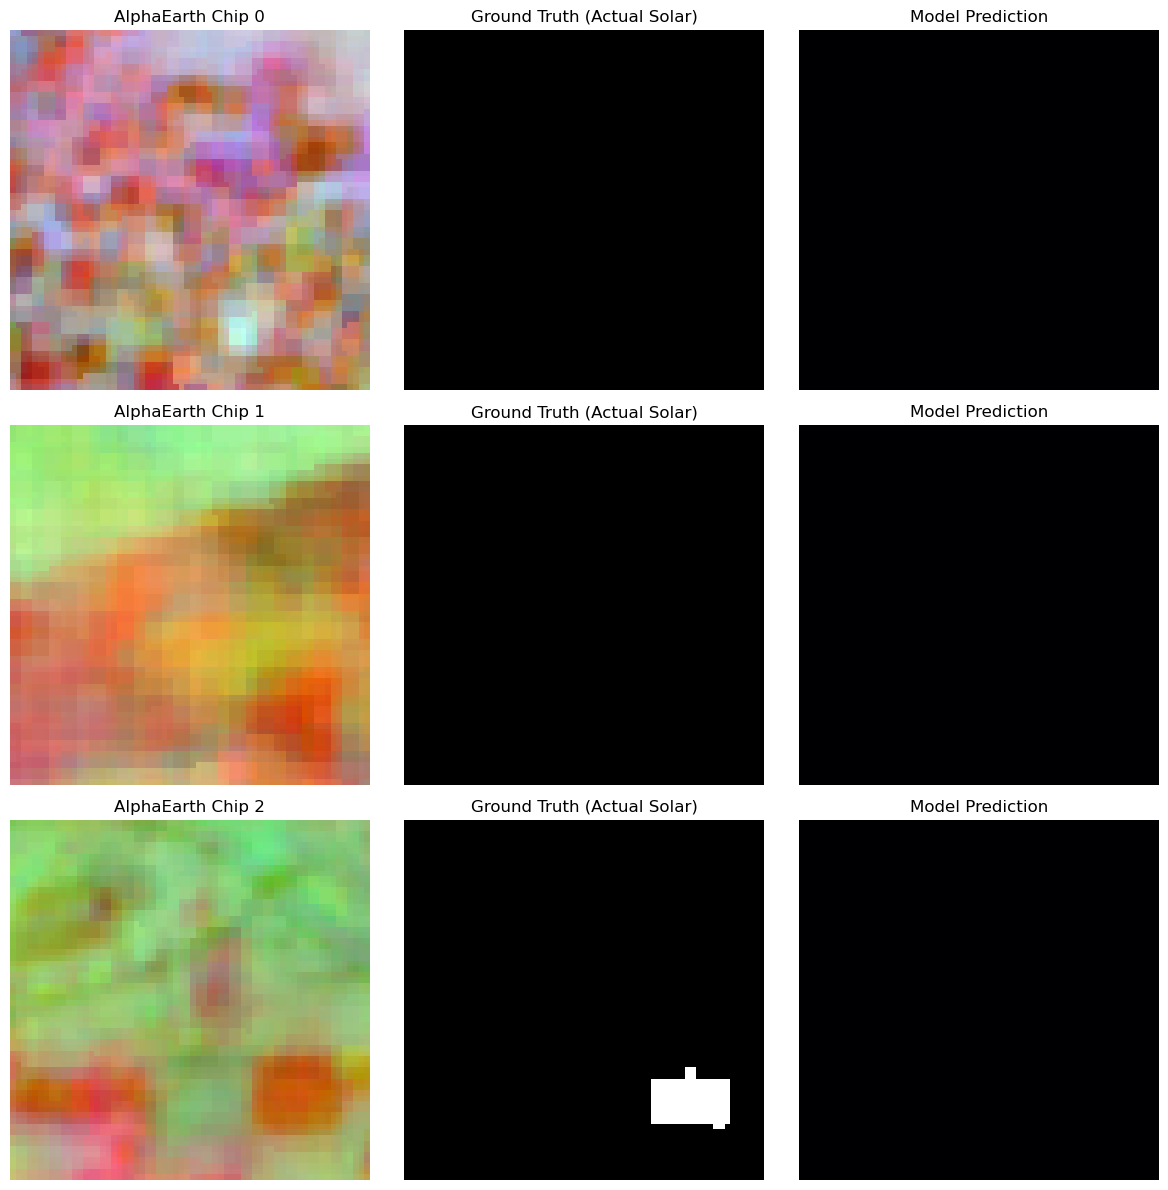

In [14]:
import matplotlib.pyplot as plt
import torch

# Put model in eval mode
model.eval()

# Grab one single batch from the validation loader
images, masks = next(iter(val_loader))
images = images.to(device)

# Get predictions
with torch.no_grad():
    logits = model(images)
    # Apply sigmoid to convert raw logits into probabilities (0.0 to 1.0)
    probs = torch.sigmoid(logits)
    # Convert probabilities to a hard binary mask (1 if > 50% sure, else 0)
    preds = (probs > 0.5).float()

# Move tensors back to CPU for plotting
images_cpu = images.cpu().numpy()
masks_cpu = masks.cpu().numpy()
preds_cpu = preds.cpu().numpy()

# Plot the first 3 chips in the batch
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    # 1. Plot a pseudo-RGB image using 3 random AlphaEarth bands (e.g., bands 0, 15, 8)
    # Normalize them just so they show up on screen
    img_display = images_cpu[i, [0, 15, 8], :, :].transpose(1, 2, 0)
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
    
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"AlphaEarth Chip {i}")
    axes[i, 0].axis('off')
    
    # 2. Plot the Ground Truth Mask
    axes[i, 1].imshow(masks_cpu[i, 0, :, :], cmap='gray')
    axes[i, 1].set_title("Ground Truth (Actual Solar)")
    axes[i, 1].axis('off')
    
    # 3. Plot the Model's Prediction
    axes[i, 2].imshow(preds_cpu[i, 0, :, :], cmap='magma')
    axes[i, 2].set_title("Model Prediction")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

In [16]:
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

# ==============================================================================
# 1. THE NATIVE LOSS SETUP (APPLE SILICON SAFE)
# ==============================================================================
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# We can keep SMP's Dice Loss because it doesn't have the MPS bug
dice_loss_fn = smp.losses.DiceLoss(mode='binary')

def native_focal_loss(inputs, targets, alpha=0.25, gamma=2.0):
    """A pure PyTorch implementation of Focal Loss that bypasses the SMP MPS bug."""
    # 1. Calculate standard BCE with logits (No reduction yet so we get pixel-by-pixel loss)
    bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
    
    # 2. Calculate the 'pt' value (probability of the correct class)
    pt = torch.exp(-bce_loss)
    
    # 3. Apply the Focal Loss mathematical formula
    focal_loss = alpha * (1 - pt) ** gamma * bce_loss
    
    # 4. Return the mean loss across the whole batch
    return focal_loss.mean()

def combined_loss(predictions, targets):
    """Calculates Native Focal Loss + SMP Dice Loss"""
    focal = native_focal_loss(predictions, targets)
    dice = dice_loss_fn(predictions, targets)
    
    return focal + dice

# We add the scheduler back in to help it settle as it gets closer
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# ==============================================================================
# 2. THE EXTENDED TRAINING LOOP WITH EARLY STOPPING
# ==============================================================================
EPOCHS = 200 # Massive increase, but we have a safety net!
EARLY_STOP_PATIENCE = 15
best_val_loss = float('inf')
patience_counter = 0

print(f"Starting Deep Training on {device} for up to {EPOCHS} Epochs...\n")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train() 
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, masks in train_bar:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss = 0.0
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  ")
        for images, masks in val_bar:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = combined_loss(outputs, masks)
            
            val_loss += loss.item()
            val_bar.set_postfix(loss=loss.item())
            
    avg_val_loss = val_loss / len(val_loader)
    print(f"--> Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f} | Val Loss = {avg_val_loss:.4f}")
    
    # --- SCHEDULER & EARLY STOPPING ---
    scheduler.step(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "solar_unet_focal_best.pth")
        print("    🌟 New best model saved!")
    else:
        patience_counter += 1
        print(f"    ⚠️ No improvement for {patience_counter} epochs.")
        
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 Early Stopping triggered! The model stopped learning.")
        break

Starting Deep Training on mps for up to 200 Epochs...



Epoch 1/200 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  8.06it/s, loss=0.78] 


--> Epoch 1: Train Loss = 0.4021 | Val Loss = 0.6007
    🌟 New best model saved!


Epoch 2/200 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  8.01it/s, loss=0.674]


--> Epoch 2: Train Loss = 0.3544 | Val Loss = 0.5961
    🌟 New best model saved!


...

--> Epoch 15: Train Loss = 0.2049 | Val Loss = 0.6204
    ⚠️ No improvement for 13 epochs.


Epoch 16/200 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  7.80it/s, loss=0.943]


--> Epoch 16: Train Loss = 0.1952 | Val Loss = 0.6162
    ⚠️ No improvement for 14 epochs.


Epoch 17/200 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  8.16it/s, loss=0.928]

--> Epoch 17: Train Loss = 0.1976 | Val Loss = 0.6210
    ⚠️ No improvement for 15 epochs.

🛑 Early Stopping triggered! The model stopped learning.


Hunting for random positive chips...
Found them! Generating predictions...


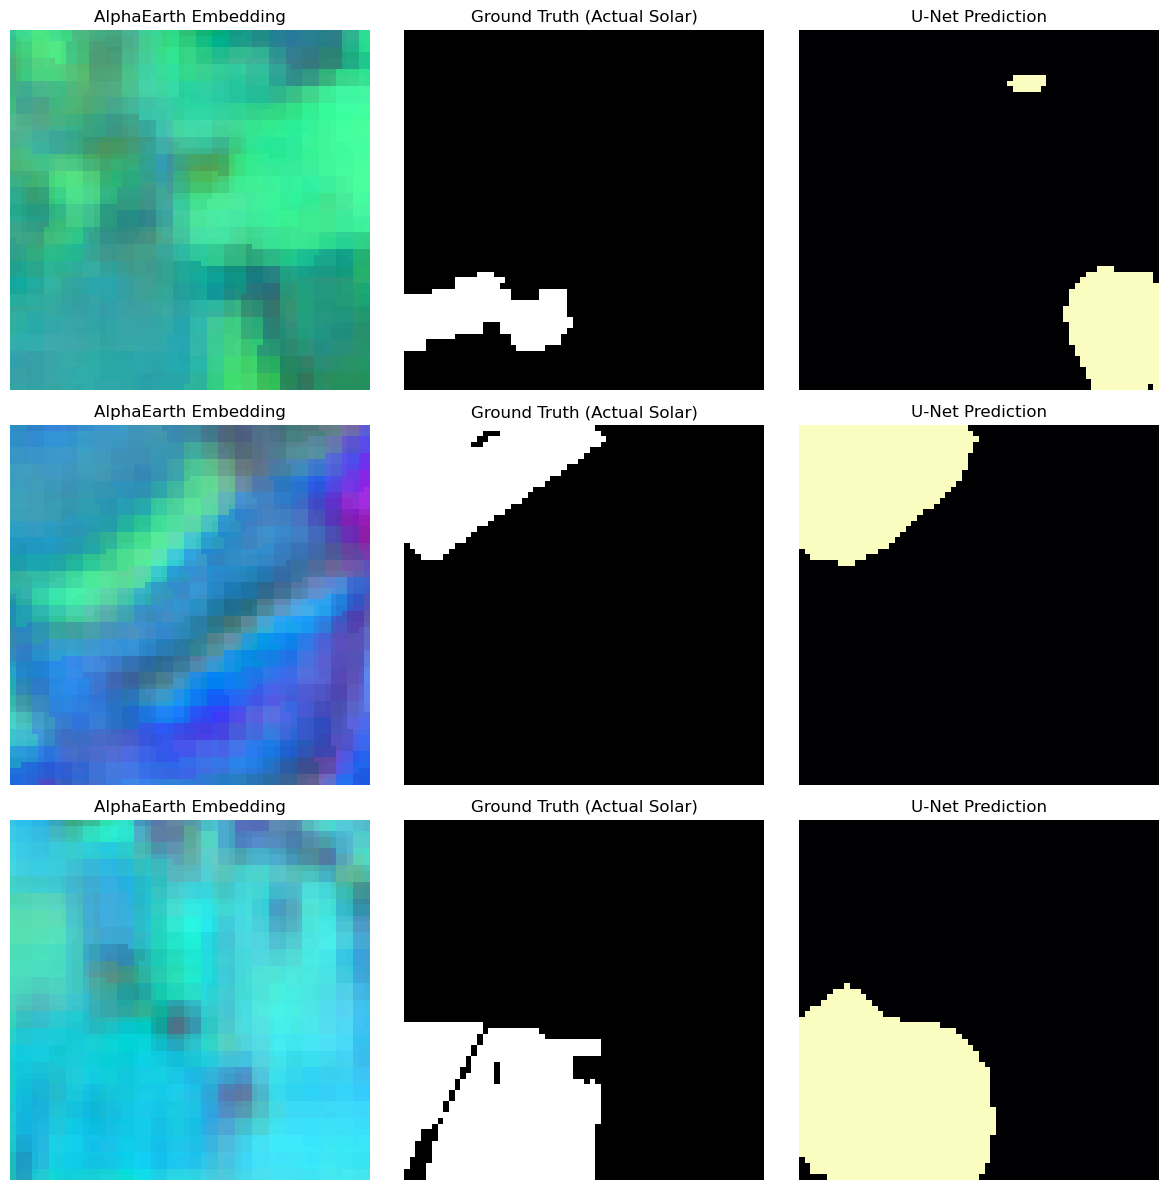

In [18]:
import matplotlib.pyplot as plt
import torch
import random

# Make sure your model is in evaluation mode
model.eval()

# 1. Find 3 random POSITIVE chips from the validation dataset
positive_samples = []
search_indices = list(range(len(val_dataset)))
random.shuffle(search_indices) # Shuffle the deck!

print("Hunting for random positive chips...")
for idx in search_indices:
    image_tensor, mask_tensor = val_dataset[idx]
    
    # Check if there is actual solar panel data in this chip
    if mask_tensor.max() > 0:
        positive_samples.append((image_tensor, mask_tensor))
        
    # Stop searching once we have 3 good examples
    if len(positive_samples) == 3:
        break

if not positive_samples:
    print("Could not find any positive validation chips!")
else:
    print("Found them! Generating predictions...")
    # 2. Stack them into a mini-batch and push to GPU
    images = torch.stack([s[0] for s in positive_samples]).to(device)
    masks = torch.stack([s[1] for s in positive_samples]).to(device)

    # 3. Generate Predictions
    with torch.no_grad():
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

    # Move back to CPU for plotting
    images_cpu = images.cpu().numpy()
    masks_cpu = masks.cpu().numpy()
    preds_cpu = preds.cpu().numpy()

    # 4. Plot them!
    fig, axes = plt.subplots(len(positive_samples), 3, figsize=(12, 4 * len(positive_samples)))

    # Handle the edge case where we only found 1 sample
    if len(positive_samples) == 1:
        axes = [axes]

    for row in range(len(positive_samples)):
        # Pick 3 random bands for a pseudo-RGB visualization
        img_display = images_cpu[row, [0, 15, 8], :, :].transpose(1, 2, 0)
        img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
        
        # Left: AlphaEarth Raw Data
        axes[row][0].imshow(img_display)
        axes[row][0].set_title(f"AlphaEarth Embedding")
        axes[row][0].axis('off')
        
        # Middle: Ground Truth Mask
        axes[row][1].imshow(masks_cpu[row, 0, :, :], cmap='gray')
        axes[row][1].set_title("Ground Truth (Actual Solar)")
        axes[row][1].axis('off')
        
        # Right: U-Net Prediction
        axes[row][2].imshow(preds_cpu[row, 0, :, :], cmap='magma')
        axes[row][2].set_title("U-Net Prediction")
        axes[row][2].axis('off')

    plt.tight_layout()
    plt.show()

In [19]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

class SolarDataset(Dataset):
    def __init__(self, image_paths, mask_paths, augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.augment = augment # NEW: Flag to enable augmentation

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Load the raw .npy files
        img_arr = np.load(self.image_paths[idx])
        mask_arr = np.load(self.mask_paths[idx])

        # 2. Axis Swapping: (H, W, C) -> (C, H, W)
        img_arr = img_arr.transpose((2, 0, 1))
        mask_arr = np.expand_dims(mask_arr, axis=0)

        # 3. Convert to PyTorch Tensors
        image_tensor = torch.from_numpy(img_arr).float()
        mask_tensor = torch.from_numpy(mask_arr).float()

        # ==========================================
        # 4. NATIVE PYTORCH SPATIAL AUGMENTATION
        # ==========================================
        if self.augment:
            # A. Random Horizontal Flip (50% chance)
            if torch.rand(1) > 0.5:
                # dims=[2] targets the Width dimension
                image_tensor = torch.flip(image_tensor, dims=[2])
                mask_tensor = torch.flip(mask_tensor, dims=[2])

            # B. Random Vertical Flip (50% chance)
            if torch.rand(1) > 0.5:
                # dims=[1] targets the Height dimension
                image_tensor = torch.flip(image_tensor, dims=[1])
                mask_tensor = torch.flip(mask_tensor, dims=[1])

            # C. Random 90-degree Rotation
            # Picks a random integer between 0 and 3 (representing 0, 90, 180, or 270 degrees)
            k = torch.randint(0, 4, (1,)).item()
            if k > 0:
                # dims=[1, 2] tells it to rotate along the Height/Width plane
                image_tensor = torch.rot90(image_tensor, k, dims=[1, 2])
                mask_tensor = torch.rot90(mask_tensor, k, dims=[1, 2])

        return image_tensor, mask_tensor

In [20]:
# Turn augmentation ON for training
train_dataset = SolarDataset(train_imgs, train_masks, augment=True)

# Validation MUST remain untouched (augment=False by default)
val_dataset = SolarDataset(val_imgs, val_masks, augment=False)

# Re-create the loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [22]:
model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights=None,           
    in_channels=64,                 
    classes=1,                      
    activation=None                 
)
model = model.to(device)

In [23]:
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

# ==============================================================================
# 1. THE NATIVE LOSS SETUP (APPLE SILICON SAFE)
# ==============================================================================
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# We can keep SMP's Dice Loss because it doesn't have the MPS bug
dice_loss_fn = smp.losses.DiceLoss(mode='binary')

def native_focal_loss(inputs, targets, alpha=0.25, gamma=2.0):
    """A pure PyTorch implementation of Focal Loss that bypasses the SMP MPS bug."""
    # 1. Calculate standard BCE with logits (No reduction yet so we get pixel-by-pixel loss)
    bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
    
    # 2. Calculate the 'pt' value (probability of the correct class)
    pt = torch.exp(-bce_loss)
    
    # 3. Apply the Focal Loss mathematical formula
    focal_loss = alpha * (1 - pt) ** gamma * bce_loss
    
    # 4. Return the mean loss across the whole batch
    return focal_loss.mean()

def combined_loss(predictions, targets):
    """Calculates Native Focal Loss + SMP Dice Loss"""
    focal = native_focal_loss(predictions, targets)
    dice = dice_loss_fn(predictions, targets)
    
    return focal + dice

# We add the scheduler back in to help it settle as it gets closer
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# ==============================================================================
# 2. THE EXTENDED TRAINING LOOP WITH EARLY STOPPING
# ==============================================================================
EPOCHS = 200 # Massive increase, but we have a safety net!
EARLY_STOP_PATIENCE = 15
best_val_loss = float('inf')
patience_counter = 0

print(f"Starting Deep Training on {device} for up to {EPOCHS} Epochs...\n")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train() 
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, masks in train_bar:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss = 0.0
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  ")
        for images, masks in val_bar:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = combined_loss(outputs, masks)
            
            val_loss += loss.item()
            val_bar.set_postfix(loss=loss.item())
            
    avg_val_loss = val_loss / len(val_loader)
    print(f"--> Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f} | Val Loss = {avg_val_loss:.4f}")
    
    # --- SCHEDULER & EARLY STOPPING ---
    scheduler.step(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "solar_unet_focal_best.pth")
        print("    🌟 New best model saved!")
    else:
        patience_counter += 1
        print(f"    ⚠️ No improvement for {patience_counter} epochs.")
        
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 Early Stopping triggered! The model stopped learning.")
        break

Starting Deep Training on mps for up to 200 Epochs...



Epoch 1/200 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  7.81it/s, loss=0.943]


--> Epoch 1: Train Loss = 0.8464 | Val Loss = 0.8164
    🌟 New best model saved!


Epoch 2/200 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  7.75it/s, loss=0.943]


--> Epoch 2: Train Loss = 0.7932 | Val Loss = 0.7853
    🌟 New best model saved!


...

--> Epoch 94: Train Loss = 0.2903 | Val Loss = 0.4917
    ⚠️ No improvement for 13 epochs.


Epoch 95/200 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  7.38it/s, loss=0.644]


--> Epoch 95: Train Loss = 0.2944 | Val Loss = 0.4940
    ⚠️ No improvement for 14 epochs.


Epoch 96/200 [Val]  : 100%|██████████| 41/41 [00:05<00:00,  7.91it/s, loss=0.655]

--> Epoch 96: Train Loss = 0.2893 | Val Loss = 0.4947
    ⚠️ No improvement for 15 epochs.

🛑 Early Stopping triggered! The model stopped learning.


/tmp/ipykernel_19938/2048988967.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("solar_unet_focal_best.pth", map_location=device))


Running validation set through the model to gather pixel probabilities...


Evaluating: 100%|██████████| 41/41 [00:05<00:00,  6.97it/s]


Calculating Precision-Recall math...

🎯 MODEL PERFORMANCE REPORT
Overall Quality (AP): 0.6226
Optimal Threshold:    0.1837
Best F1-Score:        0.6093
----------------------------------------
If you use Threshold 0.18:
-> Precision:         0.6365 (Accuracy when guessing)
-> Recall:            0.5843 (Total footprint discovered)



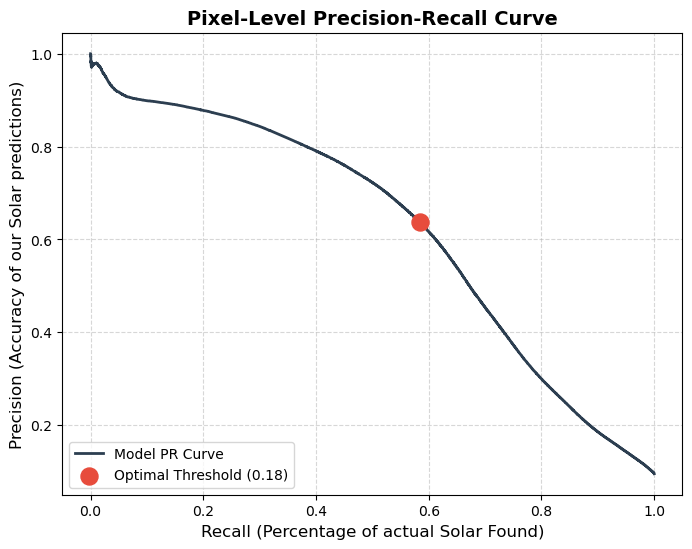

In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, average_precision_score
from tqdm import tqdm

# ==============================================================================
# 1. GATHER ALL PREDICTIONS
# ==============================================================================
# Load your best weights just to be absolutely sure we are using the Epoch 82 brain
model.load_state_dict(torch.load("solar_unet_focal_best.pth", map_location=device))
model.eval()

all_probs = []
all_masks = []

print("Running validation set through the model to gather pixel probabilities...")
with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        
        # Get raw logits and convert to 0.0 - 1.0 probabilities
        logits = model(images)
        probs = torch.sigmoid(logits)
        
        # Move back to CPU, flatten the 2D images into a massive 1D list of pixels
        all_probs.append(probs.cpu().numpy().flatten())
        all_masks.append(masks.cpu().numpy().flatten())

# Concatenate the lists into massive arrays
all_probs = np.concatenate(all_probs)
all_masks = np.concatenate(all_masks)

# ==============================================================================
# 2. CALCULATE METRICS & FIND THE SWEET SPOT
# ==============================================================================
print("Calculating Precision-Recall math...")
# This function calculates the Precision and Recall for every possible threshold
precision, recall, thresholds = precision_recall_curve(all_masks, all_probs)

# Calculate the F1-Score for every threshold. 
# F1 is the "harmonic mean" that beautifully balances Precision and Recall.
# (We drop the last item [:-1] because the thresholds array is 1 item shorter than the precision array)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

# Find the exact index of the highest F1-Score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\n" + "="*40)
print(f"🎯 MODEL PERFORMANCE REPORT")
print(f"="*40)
print(f"Overall Quality (AP): {average_precision_score(all_masks, all_probs):.4f}")
print(f"Optimal Threshold:    {best_threshold:.4f}")
print(f"Best F1-Score:        {f1_scores[best_idx]:.4f}")
print(f"----------------------------------------")
print(f"If you use Threshold {best_threshold:.2f}:")
print(f"-> Precision:         {precision[best_idx]:.4f} (Accuracy when guessing)")
print(f"-> Recall:            {recall[best_idx]:.4f} (Total footprint discovered)")
print(f"="*40 + "\n")

# ==============================================================================
# 3. PLOT THE CURVE FOR YOUR MEETING
# ==============================================================================
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#2c3e50', linewidth=2, label='Model PR Curve')

# Plot a big red dot right on the optimal threshold
plt.scatter(
    recall[best_idx], precision[best_idx], 
    color='#e74c3c', s=150, zorder=5, 
    label=f'Optimal Threshold ({best_threshold:.2f})'
)

plt.title('Pixel-Level Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Percentage of actual Solar Found)', fontsize=12)
plt.ylabel('Precision (Accuracy of our Solar predictions)', fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.5)

# A perfect model hugs the top right corner. The closer this curve is to the top right, the better!
plt.show()

Hunting for random positive chips...
Found them! Generating predictions...


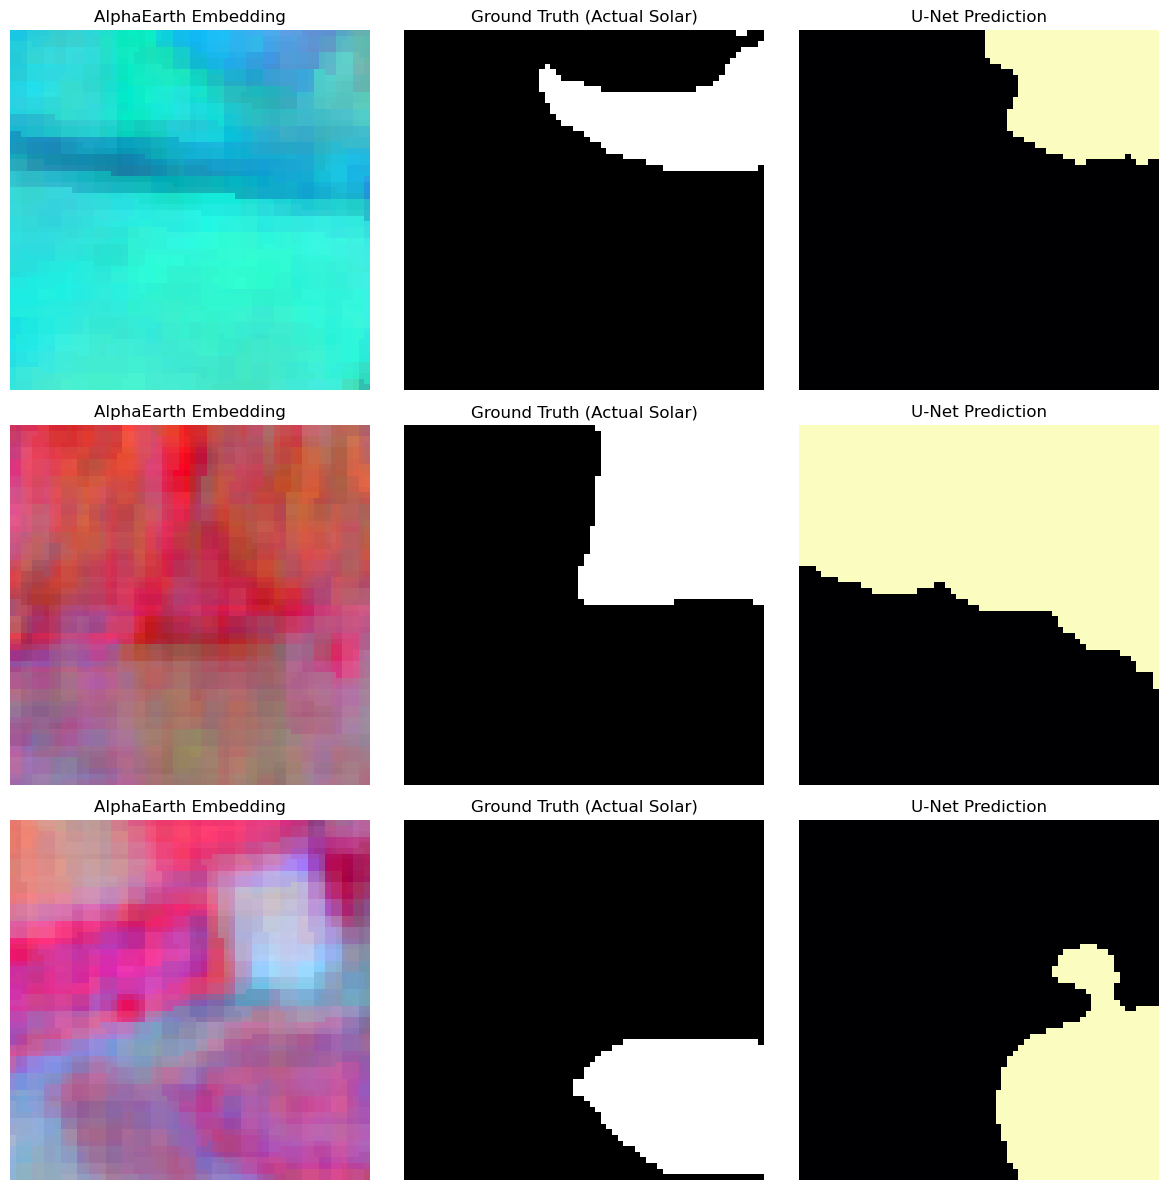

In [37]:
import matplotlib.pyplot as plt
import torch
import random

# Make sure your model is in evaluation mode
model.eval()

# 1. Find 3 random POSITIVE chips from the validation dataset
positive_samples = []
search_indices = list(range(len(val_dataset)))
random.shuffle(search_indices) # Shuffle the deck!

print("Hunting for random positive chips...")
for idx in search_indices:
    image_tensor, mask_tensor = val_dataset[idx]
    
    # Check if there is actual solar panel data in this chip
    if mask_tensor.max() > 0:
        positive_samples.append((image_tensor, mask_tensor))
        
    # Stop searching once we have 3 good examples
    if len(positive_samples) == 3:
        break

if not positive_samples:
    print("Could not find any positive validation chips!")
else:
    print("Found them! Generating predictions...")
    # 2. Stack them into a mini-batch and push to GPU
    images = torch.stack([s[0] for s in positive_samples]).to(device)
    masks = torch.stack([s[1] for s in positive_samples]).to(device)

    # 3. Generate Predictions
    with torch.no_grad():
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.18).float()

    # Move back to CPU for plotting
    images_cpu = images.cpu().numpy()
    masks_cpu = masks.cpu().numpy()
    preds_cpu = preds.cpu().numpy()

    # 4. Plot them!
    fig, axes = plt.subplots(len(positive_samples), 3, figsize=(12, 4 * len(positive_samples)))

    # Handle the edge case where we only found 1 sample
    if len(positive_samples) == 1:
        axes = [axes]

    for row in range(len(positive_samples)):
        # Pick 3 random bands for a pseudo-RGB visualization
        img_display = images_cpu[row, [0, 15, 8], :, :].transpose(1, 2, 0)
        img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
        
        # Left: AlphaEarth Raw Data
        axes[row][0].imshow(img_display)
        axes[row][0].set_title(f"AlphaEarth Embedding")
        axes[row][0].axis('off')
        
        # Middle: Ground Truth Mask
        axes[row][1].imshow(masks_cpu[row, 0, :, :], cmap='gray')
        axes[row][1].set_title("Ground Truth (Actual Solar)")
        axes[row][1].axis('off')
        
        # Right: U-Net Prediction
        axes[row][2].imshow(preds_cpu[row, 0, :, :], cmap='magma')
        axes[row][2].set_title("U-Net Prediction")
        axes[row][2].axis('off')

    plt.tight_layout()
    plt.show()